# **CS 483 Project Code**

---



###**Group Name: Smart Voyage**

Group Members: Muhammed Arabi, Shuroq Hussein, Sarah Syeda


##**Setup**

In [ ]:
!pip -q install pyspark
!apt-get -qq update
!apt-get -qq install -y openjdk-11-jdk-headless
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#add shortcut for our project folder (CS 483 project) to "MyDrive" so its not just in shared with me, so you can use the file path below

TOURISM_DATA_PATH = "/content/drive/MyDrive/CS 483 Project/Datasets/Tourism.csv"
CLIMATE_DATA_PATH = "/content/drive/MyDrive/CS 483 Project/Datasets/Climate.csv"

print("Tourism exists?", os.path.exists(TOURISM_DATA_PATH))
print("Climate exists?", os.path.exists(CLIMATE_DATA_PATH))

Mounted at /content/drive
Tourism exists? True
Climate exists? True


---

##**Data Cleaning and Formatting (Muhammed)**

Load Data:

Loads both CSV datasets from Google Drive into Spark DataFrames (tourism_raw and climate_raw) and prints their row/column counts. This confirms input data was successfully read and gives an initial sense of dataset size.


In [ ]:
from pyspark.sql import functions as F

tourism_raw = (spark.read.option("header", True).option("inferSchema", True).csv(TOURISM_DATA_PATH))

climate_raw = (spark.read.option("header", True).option("inferSchema", True).csv(CLIMATE_DATA_PATH))

print("Tourism rows:", tourism_raw.count(), ", cols:", len(tourism_raw.columns))
print("Climate rows:", climate_raw.count(), ", cols:", len(climate_raw.columns))



Tourism rows: 6650 , cols: 11
Climate rows: 20740 , cols: 5


Dataset Overview:

inspects both datasets by printing schemas, showing sample rows, and computing missing values per column. The goal is to understand the structure (column names/types) and identify where missing data exists before cleaning and merging.

In [ ]:
tourism_raw.printSchema()
climate_raw.printSchema()

display(tourism_raw.limit(5).toPandas())
display(climate_raw.limit(5).toPandas())

from pyspark.sql.functions import col, sum as spark_sum

def missing_summary(df):
    return df.select([
        spark_sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])

print("Tourism missing values (by column):")
display(missing_summary(tourism_raw).toPandas())

print("Climate missing values (by column):")
display(missing_summary(climate_raw).toPandas())

root
 |-- country: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- tourism_receipts: double (nullable = true)
 |-- tourism_arrivals: double (nullable = true)
 |-- tourism_exports: double (nullable = true)
 |-- tourism_departures: double (nullable = true)
 |-- tourism_expenditures: double (nullable = true)
 |-- gdp: double (nullable = true)
 |-- inflation: double (nullable = true)
 |-- unemployment: double (nullable = true)

root
 |-- Country: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Annual Mean: double (nullable = true)
 |-- 5-yr smooth: double (nullable = true)
 |-- Code: string (nullable = true)



,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,NaN,9.495387,1.722905e+09,2.280372,NaN
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,NaN,7.760536,2.654293e+11,7.819865,NaN
2,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,NaN,6.147291,1.394683e+11,0.372266,NaN
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,NaN,2.489638,6.152923e+09,248.195902,NaN


,Country,Year,Annual Mean,5-yr smooth,Code
0,Dominican Republic,1901,23.71,23.65,DOM
1,Dominican Republic,1902,23.40,23.52,DOM
2,Dominican Republic,1903,23.45,23.38,DOM
3,Dominican Republic,1904,23.03,23.26,DOM
4,Dominican Republic,1905,23.44,23.16,DOM


Tourism missing values (by column):


,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,0,0,0,2331,1701,2536,4061,2477,226,982,2992


Climate missing values (by column):


,Country,Year,Annual Mean,5-yr smooth,Code
0,0,0,0,0,0


Cleaning:

standardizes and filters the datasets into the minimal fields needed for the project:

- Tourism: keeps country, year, arrivals and receipts, trims country names, filters to years since 1999, and removes duplicates per (country, year).

- Climate: keeps Country, dt, and temperature, trims country names, extracts year from the date,  years since 1999, and drops rows with missing temperatures.
The goal is to create consistent, model ready tables with reliable types and a consistent time range.

In [ ]:
#Tourism data cleaning:
tourism = (tourism_raw
    .select(
        F.col("country").alias("country"),
        F.col("year").cast("int").alias("year"),
        F.col("tourism_arrivals").cast("double").alias("tourism_arrivals"),
        F.col("tourism_receipts").cast("double").alias("tourism_receipts"),

        F.col("gdp").cast("double").alias("gdp"),
    )
    .withColumn("country", F.trim(F.col("country")))
    .filter(F.col("year") >= 1999)
    .dropna(subset=["country","year"])
    .dropDuplicates(["country","year"])
)

print("Tourism cleaned rows:", tourism.count())
display(tourism.orderBy("country","year").limit(10).toPandas())

#Climate data cleaning:
climate = (climate_raw
    .select(
        F.col("Country").alias("country"),
        F.col("Year").cast("int").alias("year"),
        F.col("Annual Mean").cast("double").alias("avg_temp"),
        F.col("5-yr smooth").cast("double").alias("temp_5yr_smooth"),
        F.col("Code").alias("iso_code")
    )
    .withColumn("country", F.trim(F.col("country")))
    .filter(F.col("year") >= 1999)
    .dropna(subset=["country","year","avg_temp"])
)
#Remove regional entities
exclude_keywords = [
    "Asia", "Europe", "World", "income", "OECD",
    "Latin America", "Caribbean", "Sub-Saharan", "North America"
]

for word in exclude_keywords:
    tourism = tourism.filter(~F.col("country").contains(word))

print("Rows after removing regional aggregates:", tourism.count())
display(tourism.select("country").distinct().orderBy("country").toPandas())

print("Climate cleaned rows:", climate.count())
display(climate.orderBy("country","year").limit(10).toPandas())

Tourism cleaned rows: 6650


,country,year,tourism_arrivals,tourism_receipts,gdp
0,Afghanistan,1999,NaN,NaN,NaN
1,Afghanistan,2000,NaN,NaN,3.521418e+09
2,Afghanistan,2001,NaN,NaN,2.813572e+09
3,Afghanistan,2002,NaN,NaN,3.825701e+09
4,Afghanistan,2003,NaN,NaN,4.520947e+09
5,Afghanistan,2004,NaN,NaN,5.224897e+09
6,Afghanistan,2005,NaN,NaN,6.203257e+09
7,Afghanistan,2006,NaN,NaN,6.971758e+09
8,Afghanistan,2007,NaN,NaN,9.747886e+09
9,Afghanistan,2008,NaN,57000000.0,1.010930e+10


Rows after removing regional aggregates: 5950


,country
0,Afghanistan
1,Africa Eastern and Southern
2,Africa Western and Central
3,Albania
4,Algeria
...,...
233,Virgin Islands (U.S.)
234,West Bank and Gaza
235,"Yemen, Rep."
236,Zambia


Climate cleaned rows: 4080


,country,year,avg_temp,temp_5yr_smooth,iso_code
0,Afghanistan,1999,13.83,13.28,AFG
1,Afghanistan,2000,13.46,13.48,AFG
2,Afghanistan,2001,13.80,13.63,AFG
3,Afghanistan,2002,13.61,13.70,AFG
4,Afghanistan,2003,13.11,13.70,AFG
5,Afghanistan,2004,13.87,13.66,AFG
6,Afghanistan,2005,13.14,13.60,AFG
7,Afghanistan,2006,13.89,13.54,AFG
8,Afghanistan,2007,13.48,13.52,AFG
9,Afghanistan,2008,13.63,13.52,AFG


Merge:

converts climate data from monthly to yearly by averaging temperatures for each country-year. Then it merges (inner joins) the tourism and climate yearly tables on (country, year) and drops rows missing key modeling fields. The result is a single country year dataset containing both tourism and climate variables.

In [ ]:
# monthly to yearly avg temperature
climate_for_merge = climate.select("country", "year", F.col("temp_5yr_smooth").alias("avg_temp"))


#Merge tourism and climate
df_merged = (tourism
    .join(climate, on=["country","year"], how="inner")
    .dropna(subset=["tourism_arrivals","tourism_receipts","avg_temp"])
)

print("Merged rows:", df_merged.count())
display(df_merged.orderBy("country","year").limit(10).toPandas())

Merged rows: 2543


,country,year,tourism_arrivals,tourism_receipts,gdp,avg_temp,temp_5yr_smooth,iso_code
0,Albania,1999,371000.0,2.180000e+08,3.212122e+09,12.46,12.25,ALB
1,Albania,2000,317000.0,3.980000e+08,3.480355e+09,12.73,12.38,ALB
2,Albania,2001,354000.0,4.510000e+08,3.922101e+09,12.46,12.45,ALB
3,Albania,2002,470000.0,4.920000e+08,4.348068e+09,12.54,12.46,ALB
4,Albania,2003,557000.0,5.370000e+08,5.611496e+09,12.41,12.41,ALB
5,Albania,2004,645000.0,7.560000e+08,7.184686e+09,12.10,12.34,ALB
6,Albania,2005,748000.0,8.800000e+08,8.052077e+09,11.66,12.28,ALB
7,Albania,2006,937000.0,1.057000e+09,8.896075e+09,12.08,12.25,ALB
8,Albania,2007,1127000.0,1.479000e+09,1.067732e+10,12.74,12.29,ALB
9,Albania,2008,1420000.0,1.850000e+09,1.288135e+10,12.84,12.38,ALB


Feature Engineering:

creates modeling features that reflect “travel desirability" over time:

- Spending intensity: receipts per arrival
- Year-over-year growth: arrivals growth, receipts growth, receipts-per-arrival growth (via lag features)
- Climate change: year-over-year temperature change
It drops the first year per country and any rows where growth values can’t be computed. This produces a compact dataset of trend-based features for ML and clustering.

In [ ]:
from pyspark.sql.window import Window

w = Window.partitionBy("country").orderBy("year")

df_feat = (df_merged
    # Spending intensity
    .withColumn(
        "receipts_per_arrival",
        F.col("tourism_receipts") / F.when(F.col("tourism_arrivals") == 0, None).otherwise(F.col("tourism_arrivals"))
    )

    # Lags
    .withColumn("arrivals_prev", F.lag("tourism_arrivals").over(w))
    .withColumn("receipts_prev", F.lag("tourism_receipts").over(w))
    .withColumn("rpa_prev", F.lag("receipts_per_arrival").over(w))
    .withColumn("temp_prev", F.lag("avg_temp").over(w))

    # YoY growth
    .withColumn("arrivals_growth", (F.col("tourism_arrivals") - F.col("arrivals_prev")) / F.col("arrivals_prev"))
    .withColumn("receipts_growth", (F.col("tourism_receipts") - F.col("receipts_prev")) / F.col("receipts_prev"))
    .withColumn("rpa_growth", (F.col("receipts_per_arrival") - F.col("rpa_prev")) / F.col("rpa_prev"))

    # Temp change
    .withColumn("temp_change", F.col("avg_temp") - F.col("temp_prev"))

    # Remove first year per country and invalid rows
    .dropna(subset=["receipts_per_arrival","arrivals_growth","receipts_growth","rpa_growth","temp_change"])
)

print("Feature rows:", df_feat.count())
display(df_feat.select(
    "country","year",
    "tourism_arrivals","tourism_receipts","avg_temp",
    "receipts_per_arrival","arrivals_growth","rpa_growth","temp_change"
).orderBy("country","year").limit(10).toPandas())

Feature rows: 2395


,country,year,tourism_arrivals,tourism_receipts,avg_temp,receipts_per_arrival,arrivals_growth,rpa_growth,temp_change
0,Albania,2000,317000.0,3.980000e+08,12.73,1255.520505,-0.145553,1.136689,0.27
1,Albania,2001,354000.0,4.510000e+08,12.46,1274.011299,0.116719,0.014728,-0.27
2,Albania,2002,470000.0,4.920000e+08,12.54,1046.808511,0.327684,-0.178337,0.08
3,Albania,2003,557000.0,5.370000e+08,12.41,964.093357,0.185106,-0.079017,-0.13
4,Albania,2004,645000.0,7.560000e+08,12.10,1172.093023,0.157989,0.215746,-0.31
5,Albania,2005,748000.0,8.800000e+08,11.66,1176.470588,0.159690,0.003735,-0.44
6,Albania,2006,937000.0,1.057000e+09,12.08,1128.068303,0.252674,-0.041142,0.42
7,Albania,2007,1127000.0,1.479000e+09,12.74,1312.333629,0.202775,0.163346,0.66
8,Albania,2008,1420000.0,1.850000e+09,12.84,1302.816901,0.259982,-0.007252,0.10
9,Albania,2009,1856000.0,2.013000e+09,12.69,1084.590517,0.307042,-0.167503,-0.15


Labels: (increasing / stable / decreasing)

converts continuous trend signals into a supervised learning target:

- Computes a trend_score using a weighted combination of arrivals growth and spending-intensity growth.
- Assigns label_str as increasing, stable, or decreasing based on threshold rules.
This creates the classification target needed for the supervised BigDM algorithm.

In [ ]:
df_labeled = (df_feat
    .withColumn("trend_score", 0.6*F.col("arrivals_growth") + 0.4*F.col("rpa_growth"))
    .withColumn(
        "label_str",
        F.when(F.col("trend_score") >= 0.05, F.lit("increasing"))
         .when(F.col("trend_score") <= -0.05, F.lit("decreasing"))
         .otherwise(F.lit("stable"))
    )
)

print("Label distribution:")
display(df_labeled.groupBy("label_str").count().orderBy(F.desc("count")).toPandas())

Label distribution:


,label_str,count
0,increasing,1083
1,stable,1038
2,decreasing,274


Save new dataset:

Saves the final cleaned dataset back to Google Drive as cleaned_data.csv. It writes using Spark (which outputs a folder with part files), then moves the single part file into a single CSV named cleaned_data.csv for easy reuse by group members.

In [ ]:
import os, shutil, glob

OUTPUT_DIR = "/content/drive/MyDrive/CS 483 Project/Datasets"
TMP_FOLDER = f"{OUTPUT_DIR}/cleaned_data_tmp"

#Writes as Spark CSV
df_labeled.coalesce(1).write.mode("overwrite").option("header", True).csv(TMP_FOLDER)

#Moves the single part file to cleaned_data.csv
part_file = glob.glob(f"{TMP_FOLDER}/part-*.csv")[0]
final_path = f"{OUTPUT_DIR}/cleaned_data.csv"

#Removes old cleaned_data.csv
if os.path.exists(final_path):
    os.remove(final_path)

shutil.move(part_file, final_path)

#Cleans up temp folder
shutil.rmtree(TMP_FOLDER)

print("Saved:", final_path)

Saved: /content/drive/MyDrive/CS 483 Project/Datasets/cleaned_data.csv


Cleaned Data Overview:

reloads cleaned_data.csv and prints basic stats (total rows and distinct country count), plus a list of countries. This verifies the saved file is readable and confirms how much usable data remains after cleaning, merging, and feature engineering.

In [ ]:
#Loads cleaned dataset

CLEANED_DATA_PATH = "/content/drive/MyDrive/CS 483 Project/Datasets/cleaned_data.csv"

cleaned_df = (spark.read.option("header", True).option("inferSchema", True).csv(CLEANED_DATA_PATH))

print("Total rows:", cleaned_df.count())

#Counts distinct countries
num_countries = cleaned_df.select("country").distinct().count()
print("Number of distinct countries:", num_countries)




#shows list of countries
display(cleaned_df.select("country").distinct().orderBy("country").toPandas())



Total rows: 2395
Number of distinct countries: 145


,country
0,Albania
1,Algeria
2,Angola
3,Argentina
4,Armenia
...,...
140,Uruguay
141,Uzbekistan
142,Vanuatu
143,"Yemen, Rep."


---

##**BigDM Algorithm 1: Supervised Learning - Classification (initial) (Muhammed)**


In this section, we use supervised learning to classify each country’s tourism trend as increasing, stable, or decreasing. We use the cleaned dataset created earlier, which already contains tourism, climate, and GDP variables, along with the original labels from our data cleaning step. The goal of this algorithm is to learn patterns from past country-year observations and see whether a machine learning model can correctly classify tourism trend behavior.

**<h4>Load cleaned data, and Prepare ML Data:<h4/>**

This first cell loads the cleaned dataset and prepares the machine learning table. We keep the original label from the cleaned data, then build additional features that help the model understand the scale and direction of tourism change over time. We add log-transformed features so very large values are easier for the model to learn from, and we also create slope features that summarize recent tourism movement for each country. These new features make the classification model more informative while still keeping the original project labels unchanged.

In [ ]:

from pyspark.sql import SparkSession, functions as F, Window

spark = SparkSession.builder.getOrCreate()

DATA_PATH = "/content/drive/MyDrive/CS 483 Project/Datasets/cleaned_data.csv"

df = (spark.read.option("header", True).option("inferSchema", True).csv(DATA_PATH))

#Base ML table
base = (df.select("country","year",F.col("label_str").alias("label"),"arrivals_growth","receipts_growth","rpa_growth","arrivals_prev","receipts_prev","rpa_prev","temp_prev","temp_change","gdp","avg_temp","temp_5yr_smooth").dropna(subset=["country","year","label"]))

#engineered features
base = (base.withColumn("log_arr_prev", F.log(F.when(F.col("arrivals_prev") > 0, F.col("arrivals_prev")).otherwise(F.lit(None)))).withColumn("log_rec_prev", F.log(F.when(F.col("receipts_prev") > 0, F.col("receipts_prev")).otherwise(F.lit(None))))
    .withColumn("log_rpa_prev", F.log(F.when(F.col("rpa_prev") > 0, F.col("rpa_prev")).otherwise(F.lit(None))))
)

#per country recent trend over last N years
N_TREND = 5
w_year = Window.partitionBy("country").orderBy("year")

base = (base.withColumn("arr_lag", F.lag("arrivals_prev").over(w_year)).withColumn("rec_lag", F.lag("receipts_prev").over(w_year)).withColumn("rpa_lag", F.lag("rpa_prev").over(w_year))
    .withColumn("arr_logg", F.when((F.col("arrivals_prev") > 0) & (F.col("arr_lag") > 0), F.log(F.col("arrivals_prev") / F.col("arr_lag"))))
    .withColumn("rec_logg", F.when((F.col("receipts_prev") > 0) & (F.col("rec_lag") > 0), F.log(F.col("receipts_prev") / F.col("rec_lag")))).withColumn("rpa_logg", F.when((F.col("rpa_prev") > 0) & (F.col("rpa_lag") > 0), F.log(F.col("rpa_prev") / F.col("rpa_lag"))))
)

w_lastN = Window.partitionBy("country").orderBy("year").rowsBetween(-(N_TREND - 1), 0)

base = (base.withColumn("arr_slope", F.avg("arr_logg").over(w_lastN)).withColumn("rec_slope", F.avg("rec_logg").over(w_lastN)).withColumn("rpa_slope", F.avg("rpa_logg").over(w_lastN)).drop("arr_lag", "rec_lag", "rpa_lag"))

#drops rows where engineered features are null
df_ml = base.dropna(subset=["arrivals_growth","receipts_growth","rpa_growth","log_arr_prev","log_rec_prev","log_rpa_prev","arr_slope","rec_slope","rpa_slope"])

print("Rows:", df_ml.count(), "Countries:", df_ml.select("country").distinct().count())
df_ml.groupBy("label").count().orderBy(F.desc("count")).show()
df_ml.show(3, truncate=False)

Rows: 2250 Countries: 145
+----------+-----+
|     label|count|
+----------+-----+
|increasing| 1018|
|    stable|  981|
|decreasing|  251|
+----------+-----+

+-------+----+----------+------------------+-------------------+--------------------+-------------+-------------+------------------+---------+-------------------+------------------+--------+---------------+------------------+-----------------+-----------------+-------------------+-------------------+--------------------+---------------------+------------------+-------------------+
|country|year|label     |arrivals_growth   |receipts_growth    |rpa_growth          |arrivals_prev|receipts_prev|rpa_prev          |temp_prev|temp_change        |gdp               |avg_temp|temp_5yr_smooth|log_arr_prev      |log_rec_prev     |log_rpa_prev     |arr_logg           |rec_logg           |rpa_logg            |arr_slope            |rec_slope         |rpa_slope          |
+-------+----+----------+------------------+-------------------+--------

**<h4>Train Logistic Regression model and Random Forest model to get predictions:<h4/>**

We train two classification models: Logistic Regression and Random Forest. We split the data by time so that older years are used for training and newer years are used for testing. This makes the experiment more realistic because it simulates using historical information to classify future observations.

After that, we build Spark ML pipelines that index the labels, fill in missing feature values, combine all features into a vector, and train the two models. At the end of the cell, we generate predictions on the test set so we can evaluate how well each model performs.

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, Imputer, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier

TRAIN_END_YEAR = 2016
SAMPLE_FRACTION_MAIN = 0.60
SHUFFLE_PARTS = 32

spark.catalog.clearCache()
spark.conf.set("spark.sql.shuffle.partitions", str(SHUFFLE_PARTS))
spark.conf.set("spark.default.parallelism", str(SHUFFLE_PARTS))

#time split
train_df = df_ml.filter(F.col("year") <= TRAIN_END_YEAR).cache()
test_df  = df_ml.filter(F.col("year") > TRAIN_END_YEAR).cache()
_ = train_df.count(); _ = test_df.count()

#stratified sample
fractions = {"stable": SAMPLE_FRACTION_MAIN, "increasing": SAMPLE_FRACTION_MAIN, "decreasing": 1.0}

train_s = train_df.sampleBy("label", fractions=fractions, seed=42).cache()
_ = train_s.count()

print("Train(full):", train_df.count(), "Train(sample):", train_s.count(), "Test:", test_df.count())
train_s.groupBy("label").count().orderBy(F.desc("count")).show()

#class weights for LR
counts = {r["label"]: r["count"] for r in train_s.groupBy("label").count().collect()}
total = sum(counts.values())
k = len(counts)

raw_weights = {lbl: total / (k * cnt) for lbl, cnt in counts.items()}
weights = {"stable": raw_weights.get("stable", 1.0), "increasing": raw_weights.get("increasing", 1.0), "decreasing": raw_weights.get("decreasing", 1.0) * 1.35}

train_w = train_s.withColumn("classWeight", F.when(F.col("label")=="stable", F.lit(1.0)).when(F.col("label")=="increasing", F.lit(1.2)).otherwise(F.lit(2.8)))

#features
feature_cols = ["year", "arrivals_prev","receipts_prev","rpa_prev", "log_arr_prev","log_rec_prev","log_rpa_prev", "arr_slope","rec_slope","rpa_slope", "temp_prev","temp_change","gdp","avg_temp","temp_5yr_smooth"]

label_indexer = StringIndexer(inputCol="label", outputCol="labelIndex", handleInvalid="skip")
imputer = Imputer(inputCols=feature_cols, outputCols=[c+"_imp" for c in feature_cols])

assembler_raw = VectorAssembler(inputCols=[c+"_imp" for c in feature_cols], outputCol="features_raw")

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

#model 1 logistic regression
lr = LogisticRegression(featuresCol="features", labelCol="labelIndex", weightCol="classWeight", maxIter=100, regParam=0.05, elasticNetParam=0.0, family="multinomial")

lr_pipe = Pipeline(stages=[label_indexer, imputer, assembler_raw, scaler, lr])
lr_model = lr_pipe.fit(train_w)
lr_pred = lr_model.transform(test_df).cache()
_ = lr_pred.count()

#model 2 random forest
rf = RandomForestClassifier(featuresCol="features_raw", labelCol="labelIndex", numTrees=70, maxDepth=7, maxBins=32, minInstancesPerNode=5, featureSubsetStrategy="sqrt", seed=42)

rf_pipe = Pipeline(stages=[label_indexer, imputer, assembler_raw, rf])
rf_model = rf_pipe.fit(train_s)
rf_pred = rf_model.transform(test_df).cache()
_ = rf_pred.count()

LABEL_ORDER = lr_model.stages[0].labels
print("Index->Label:", list(enumerate(LABEL_ORDER)))

Train(full): 1844 Train(sample): 1108 Test: 406
+----------+-----+
|     label|count|
+----------+-----+
|increasing|  478|
|    stable|  462|
|decreasing|  168|
+----------+-----+

Index->Label: [(0, 'increasing'), (1, 'stable'), (2, 'decreasing')]


Classification Evaluation and Comparison:

- Calculates overall Accuracy and Weighted F1 on the future test set.
- Prints a confusion matrix (how often each true class is predicted as each class).
- Computes per class:
  - Precision: when it predicts a class, how often it’s right
  - Recall: how many of the true cases it finds
  - F1: balance of precision/recall

key findings: the baseline LR is decent at “stable”, but struggles more on “increasing/decreasing”

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql import functions as F
#Function to evaluate a model's predictions
def eval_model(pred_df, name):
    #Computes overall accuracy
    acc = MulticlassClassificationEvaluator(labelCol="labelIndex", predictionCol="prediction", metricName="accuracy").evaluate(pred_df)
    #Computes weighted F1 score
    wf1 = MulticlassClassificationEvaluator(labelCol="labelIndex", predictionCol="prediction", metricName="f1").evaluate(pred_df)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Weighted F1:", wf1)

    print("\nConfusion counts (true labelIndex, predicted, count):")
    cm = (pred_df.groupBy("labelIndex", "prediction").count().orderBy("labelIndex", "prediction"))
    cm.show(50, truncate=False)
    #Total actual instances per class
    true_tot = pred_df.groupBy("labelIndex").count().withColumnRenamed("count", "true_count")
    #Total predicted instances per class
    pred_tot = (pred_df.groupBy("prediction").count().withColumnRenamed("count", "pred_count").withColumn("labelIndex", F.col("prediction").cast("double")).drop("prediction"))
    #True positives per class
    tp = (pred_df.filter(F.col("labelIndex") == F.col("prediction")).groupBy("labelIndex").count().withColumnRenamed("count", "tp"))
    #Computes precision, recall, and F1 per class
    stats = (true_tot.join(tp, "labelIndex", "left").fillna({"tp": 0}).join(pred_tot, "labelIndex", "left").fillna({"pred_count": 0})
                    .withColumn("fp", F.col("pred_count") - F.col("tp")).withColumn("fn", F.col("true_count") - F.col("tp"))
                    .withColumn("precision", F.when((F.col("tp")+F.col("fp")) > 0, F.col("tp")/(F.col("tp")+F.col("fp"))).otherwise(F.lit(0.0)))
                    .withColumn("recall", F.when((F.col("tp")+F.col("fn")) > 0, F.col("tp")/(F.col("tp")+F.col("fn"))).otherwise(F.lit(0.0)))
                    .withColumn("f1", F.when((F.col("precision")+F.col("recall")) > 0, 2*F.col("precision")*F.col("recall")/(F.col("precision")+F.col("recall"))).otherwise(F.lit(0.0))).orderBy("labelIndex"))

    print("\nPer-class metrics:")
    stats.select("labelIndex","tp","fp","fn","precision","recall","f1").show(truncate=False)

    return acc, wf1, stats

#majority baseline
majority_row = test_df.groupBy("label").count().orderBy(F.desc("count")).first()
majority_label = majority_row["label"]
majority_index = LABEL_ORDER.index(majority_label)
#Predict majority class for all rows
baseline_pred = lr_pred.select("labelIndex").withColumn("prediction", F.lit(float(majority_index)))
baseline_acc, baseline_f1, baseline_stats = eval_model(baseline_pred, "Majority Baseline")
lr_acc, lr_f1, lr_stats = eval_model(lr_pred, "Logistic Regression")
rf_acc, rf_f1, rf_stats = eval_model(rf_pred, "Random Forest")

print("\nLegend (labelIndex -> label_str):", list(enumerate(LABEL_ORDER)))
#Creates summary table of model performance
summary_rows = [("Majority Baseline", float(baseline_acc), float(baseline_f1)), ("Logistic Regression", float(lr_acc), float(lr_f1)), ("Random Forest", float(rf_acc), float(rf_f1)),]

summary_df = spark.createDataFrame(summary_rows, ["model", "accuracy", "weighted_f1"])
summary_df.orderBy(F.desc("accuracy")).show(truncate=False)


Majority Baseline
Accuracy: 0.4064039408866995
Weighted F1: 0.23487443168583333

Confusion counts (true labelIndex, predicted, count):
+----------+----------+-----+
|labelIndex|prediction|count|
+----------+----------+-----+
|0.0       |1.0       |158  |
|1.0       |1.0       |165  |
|2.0       |1.0       |83   |
+----------+----------+-----+


Per-class metrics:
+----------+---+---+---+------------------+------+------------------+
|labelIndex|tp |fp |fn |precision         |recall|f1                |
+----------+---+---+---+------------------+------+------------------+
|0.0       |0  |0  |158|0.0               |0.0   |0.0               |
|1.0       |165|241|0  |0.4064039408866995|1.0   |0.5779334500875657|
|2.0       |0  |0  |83 |0.0               |0.0   |0.0               |
+----------+---+---+---+------------------+------+------------------+


Logistic Regression
Accuracy: 0.4408866995073892
Weighted F1: 0.3770336071948283

Confusion counts (true labelIndex, predicted, count):
+----

**<h4>Build 5-Year and 10-Year Future Projection Inputs:<h4/>**

After training the models, we next create future input rows for each country. This cell estimates what the feature values might look like 5 years and 10 years into the future. To do this, we use each country’s most recent known values and combine them with the average trend observed in the last few years.

In simple terms, this cell creates a projected future version of each country based on its recent tourism and climate patterns. We do not claim these are exact future values. Instead, they are reasonable scenario inputs that let the model make future classification predictions. This step is necessary because the classifier needs feature values in order to predict future tourism trend labels.

In [ ]:
from pyspark.sql import Window
from pyspark.sql import functions as F

HORIZONS = [5, 10]
N_YEARS_TREND = 5

w_year = Window.partitionBy("country").orderBy("year")
#Creates lagged values and log growth rates for tourism indicators
trend_base = (df_ml
    .withColumn("arr_lag", F.lag("arrivals_prev").over(w_year)).withColumn("rec_lag", F.lag("receipts_prev").over(w_year)).withColumn("rpa_lag", F.lag("rpa_prev").over(w_year))
    .withColumn("arr_logg", F.when((F.col("arrivals_prev") > 0) & (F.col("arr_lag") > 0), F.log(F.col("arrivals_prev") / F.col("arr_lag")))).withColumn("rec_logg", F.when((F.col("receipts_prev") > 0) & (F.col("rec_lag") > 0), F.log(F.col("receipts_prev") / F.col("rec_lag"))))
    .withColumn("rpa_logg", F.when((F.col("rpa_prev") > 0) & (F.col("rpa_lag") > 0), F.log(F.col("rpa_prev") / F.col("rpa_lag"))))
)
#Gets the most recent year available for each country
last_year = trend_base.groupBy("country").agg(F.max("year").alias("last_year"))
#Keeps the latest row per country as the base for future projection
last_row = (trend_base.join(last_year, "country").filter(F.col("year") == F.col("last_year")).select("country", F.col("last_year").alias("base_year"), F.col("arrivals_prev").alias("base_arr"), F.col("receipts_prev").alias("base_rec"),
        F.col("rpa_prev").alias("base_rpa"), F.col("temp_prev").alias("base_temp_prev"), F.col("gdp").alias("base_gdp"), F.col("avg_temp").alias("base_avg_temp"), F.col("temp_5yr_smooth").alias("base_temp_5yr_smooth"))
)

#Selects the most recent years for trend calculation
recent = (trend_base.join(last_year, "country")
    .filter(F.col("year") >= F.col("last_year") - (N_YEARS_TREND - 1))
)
#Average recent log-growth and temperature change per country
growth = (recent.groupBy("country").agg(F.avg("arr_logg").alias("arr_logg_mean"), F.avg("rec_logg").alias("rec_logg_mean"), F.avg("rpa_logg").alias("rpa_logg_mean"), F.avg("temp_change").alias("temp_change_mean"))).fillna(0.0)
#Combines latest observed values with recent trend estimates
base_future = last_row.join(growth, "country", "left").fillna(0.0)
hdf = spark.createDataFrame([(int(h),) for h in HORIZONS], ["horizon"])
#Projects future feature values using recent growth trends
future = (base_future.crossJoin(hdf)
    .withColumn("year", F.col("base_year") + F.col("horizon"))
    .withColumn("arrivals_prev", F.col("base_arr") * F.exp(F.col("horizon") * F.col("arr_logg_mean")))
    .withColumn("receipts_prev", F.col("base_rec") * F.exp(F.col("horizon") * F.col("rec_logg_mean")))
    .withColumn("rpa_prev",      F.col("base_rpa") * F.exp(F.col("horizon") * F.col("rpa_logg_mean")))
    .withColumn("temp_change", F.col("temp_change_mean"))
    .withColumn("temp_prev", F.col("base_temp_prev") + (F.col("horizon") * F.col("temp_change_mean")))
    .withColumn("gdp", F.col("base_gdp")).withColumn("avg_temp", F.col("base_avg_temp"))
    .withColumn("temp_5yr_smooth", F.col("base_temp_5yr_smooth"))
    .withColumn("log_arr_prev", F.log(F.when(F.col("arrivals_prev") > 0, F.col("arrivals_prev")).otherwise(F.lit(None))))
    .withColumn("log_rec_prev", F.log(F.when(F.col("receipts_prev") > 0, F.col("receipts_prev")).otherwise(F.lit(None))))
    .withColumn("log_rpa_prev", F.log(F.when(F.col("rpa_prev") > 0, F.col("rpa_prev")).otherwise(F.lit(None))))
    .withColumn("arr_slope", F.col("arr_logg_mean")).withColumn("rec_slope", F.col("rec_logg_mean")).withColumn("rpa_slope", F.col("rpa_logg_mean"))
    .select("country","horizon","year","arrivals_prev","receipts_prev","rpa_prev","log_arr_prev","log_rec_prev","log_rpa_prev","arr_slope","rec_slope","rpa_slope","temp_prev","temp_change","gdp","avg_temp","temp_5yr_smooth").dropna()
)

print("Future rows:", future.count())
future.show(5, truncate=False)

Future rows: 290
+---------+-------+----+--------------------+--------------------+------------------+------------------+------------------+------------------+--------------------+--------------------+---------------------+------------------+---------------------+-------------------+--------+---------------+
|country  |horizon|year|arrivals_prev       |receipts_prev       |rpa_prev          |log_arr_prev      |log_rec_prev      |log_rpa_prev      |arr_slope           |rec_slope           |rpa_slope            |temp_prev         |temp_change          |gdp                |avg_temp|temp_5yr_smooth|
+---------+-------+----+--------------------+--------------------+------------------+------------------+------------------+------------------+--------------------+--------------------+---------------------+------------------+---------------------+-------------------+--------+---------------+
|Albania  |5      |2025|1.1172566294582086E7|3.267584640346133E9 |292.4650034907991 |16.228971893500677|

**<h4>Build 5-Year and 10-Year Future Projection Inputs:<h4/>**

This uses the better-performing classification model to predict future tourism trend labels for every country. For each country, the model predicts whether tourism is most likely to be increasing, stable, or decreasing in 5 years and in 10 years.

The outputs include a wide table that shows the projected 5-year and 10-year label for each country, as well as summary tables that show how many countries fall into each category. We also display the countries with the highest probability of being increasing and the countries with the highest probability of being decreasing. These outputs make the classification results easier to interpret and connect directly to the goal of the project.

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array
#Chooses the better model based on test accuracy
pred_model = rf_model if rf_acc >= lr_acc else lr_model

future_for_pred = future.withColumn("label", F.lit("stable"))
#Generates predictions for future projected rows
pred_future = pred_model.transform(future_for_pred)
#Maps numeric prediction indexes back to label names
mapping_expr = F.create_map([F.lit(x) for x in sum([[float(i), s] for i, s in enumerate(LABEL_ORDER)], [])])
pred_future = pred_future.withColumn("pred_label", mapping_expr[F.col("prediction")])
#Selects main prediction outputs and convert probability vector to array
out = (pred_future.withColumn("prob_arr", vector_to_array("probability")).select("country","horizon","year","pred_label","probability","prob_arr").orderBy("country","horizon"))
#Creates wide table with 5-year and 10-year projected labels
wide = (out.groupBy("country").pivot("horizon", [5, 10]).agg(F.first("pred_label")).withColumnRenamed("5",  "proj_label_5y").withColumnRenamed("10", "proj_label_10y").orderBy("country"))

wide.show(50, truncate=False)
#Shows overall distribution of projected labels by forecast horizon
pred_dist = (out.groupBy("horizon", "pred_label").count().orderBy("horizon", "pred_label"))
pred_dist.show(truncate=False)
#Ranks countries by probability of increasing tourism trend in 10 years
inc_idx = LABEL_ORDER.index("increasing")
top_inc_10y = (out.filter(F.col("horizon") == 10).withColumn("p_increasing", F.col("prob_arr")[inc_idx]).orderBy(F.desc("p_increasing")).select("country","year","pred_label","p_increasing"))
top_inc_10y.show(20, truncate=False)

#Ranks countries by probability of decreasing tourism trend in 10 years
dec_idx = LABEL_ORDER.index("decreasing")
top_dec_10y = (out.filter(F.col("horizon") == 10).withColumn("p_decreasing", F.col("prob_arr")[dec_idx]).orderBy(F.desc("p_decreasing")).select("country","year","pred_label","p_decreasing"))
top_dec_10y.show(20, truncate=False)

print("Legend (probability index order):", LABEL_ORDER)
print("Model used for projection:", "Random Forest" if rf_acc >= lr_acc else "Logistic Regression")

+------------------------+-------------+--------------+
|country                 |proj_label_5y|proj_label_10y|
+------------------------+-------------+--------------+
|Albania                 |stable       |stable        |
|Algeria                 |decreasing   |decreasing    |
|Angola                  |stable       |stable        |
|Argentina               |stable       |stable        |
|Armenia                 |stable       |stable        |
|Australia               |stable       |stable        |
|Austria                 |stable       |stable        |
|Azerbaijan              |stable       |stable        |
|Bahrain                 |stable       |stable        |
|Bangladesh              |stable       |stable        |
|Barbados                |stable       |stable        |
|Belarus                 |stable       |stable        |
|Belgium                 |stable       |stable        |
|Benin                   |stable       |stable        |
|Bhutan                  |increasing   |stable  

The future projections suggest that most countries are likely to remain stable, while a smaller number are projected to become increasing or decreasing. This makes sense because tourism usually changes gradually over time rather than shifting dramatically every year. The projection outputs are useful because they help identify which countries appear to have stronger future tourism growth potential and which countries may face weaker tourism trends in the coming years.

**<h4>Visualize Model Performance and Future Predictions<h4/>**

We create visualizations to make the classification results easier to understand. We compare the models using bar charts for accuracy and weighted F1, and we also display a confusion matrix for the better model.

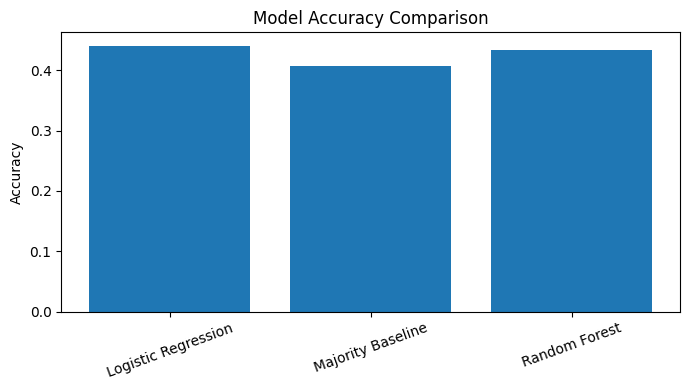

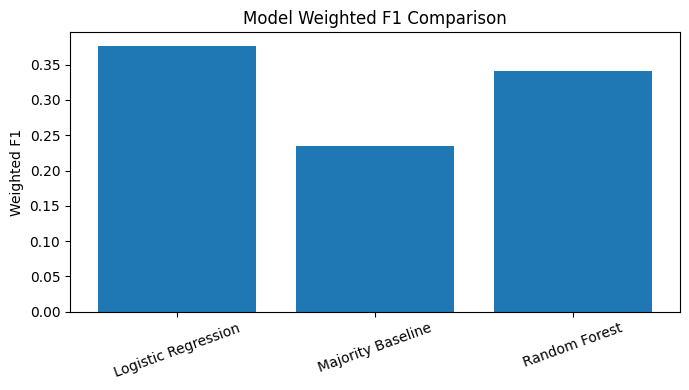

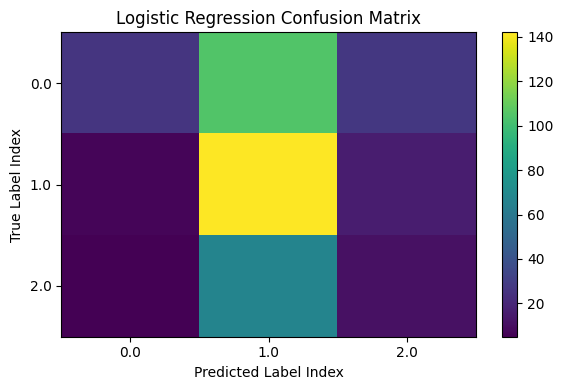

In [ ]:

import matplotlib.pyplot as plt

#model comparison
summary_pd = summary_df.orderBy("model").toPandas()

plt.figure(figsize=(7, 4))
plt.bar(summary_pd["model"], summary_pd["accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(summary_pd["model"], summary_pd["weighted_f1"])
plt.title("Model Weighted F1 Comparison")
plt.ylabel("Weighted F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


#confusion matrix for better model
best_pred = rf_pred if rf_acc >= lr_acc else lr_pred
best_name = "Random Forest" if rf_acc >= lr_acc else "Logistic Regression"

cm_pd = (best_pred.groupBy("labelIndex", "prediction").count().toPandas())

cm_pivot = cm_pd.pivot(index="labelIndex", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(6, 4))
plt.imshow(cm_pivot.values, aspect="auto")
plt.title(f"{best_name} Confusion Matrix")
plt.xlabel("Predicted Label Index")
plt.ylabel("True Label Index")
plt.xticks(range(len(cm_pivot.columns)), cm_pivot.columns)
plt.yticks(range(len(cm_pivot.index)), cm_pivot.index)
plt.colorbar()
plt.tight_layout()
plt.show()


**<h4>Conclusion:<h4/>**

The results show that Logistic Regression performed slightly better than the baseline and slightly better than Random Forest in this setup. The model was strongest at identifying the stable class, while it was weaker on increasing and decreasing. This is expected because tourism trends are affected by many outside factors, such as economic shocks, political instability, and unexpected global events, which are not fully captured in the dataset. Even so, the model still learned meaningful patterns and was useful for generating future tourism trend projections.

---

## **BigDM Algorithm 1 — Supervised Learning: Additional Classification Models (Sarah)**

In this section we train and evaluate four additional classifiers — **Gradient Boosted
Trees (GBT)**, **Decision Tree**, **Linear SVM (LinearSVC)**, and **Multilayer
Perceptron (MLP)** — on the tourism trend classification task





### Data quality fixes applied

Initial experiments produced ~42% accuracy. Iterative root-cause analysis identified
two compounding issues inherited from the original data pipeline

**Fix 1 — Label boundary noise:**
The original labels used fixed thresholds (trend_score ≥ 0.05 = increasing,
≤ −0.05 = decreasing). Analysis showed 44.6% of all observations fell within ±0.05
of zero — a country with score 0.051 was labelled "increasing" while one with 0.049
was labelled "stable", even though they are statistically identical. The classifier
failed learn from that boundary. Fixed by replacing fixed thresholds with percentile-based
labels: bottom 20% = decreasing, middle 60% = stable, top 20% = increasing.

**Fix 2 — Missing direct predictors:**
`arrivals_growth`, `receipts_growth`, and `rpa_growth` are the direct components
of `trend_score` — the formula used to derive the label — yet all three were absent
from the feature set. `rpa_growth` alone has a Pearson correlation of 0.94 with the
label. Adding all three growth rate features brought the total feature count to 18
and gave models access to the strongest available predictors.


### Load Data and Engineer Features

We reload the full cleaned dataset with all years retained, including 2020. The feature set (18 features) includes `arrivals_growth`, `receipts_growth`, and `rpa_growth` — the direct components of `trend_score` (rpa_growth has Pearson r=0.94 with the label) — as well as `year` to capture temporal context.


In [ ]:
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.ml.feature import StringIndexer, VectorAssembler, Imputer, StandardScaler
from pyspark.ml import Pipeline
import numpy as np

spark = SparkSession.builder.getOrCreate()
spark.conf.set("spark.sql.shuffle.partitions", "32")

DATA_PATH = "/content/drive/MyDrive/CS 483 Project/Datasets/cleaned_data.csv"
df_raw = (spark.read.option("header",True).option("inferSchema",True).csv(DATA_PATH))

print(f"Total rows (all years including 2020): {df_raw.count()}")

base = (df_raw.select(
    "country","year","trend_score",
    "arrivals_growth","receipts_growth","rpa_growth",
    "arrivals_prev","receipts_prev","rpa_prev","temp_prev",
    "temp_change","gdp","avg_temp","temp_5yr_smooth"
).dropna(subset=["country","year","trend_score","arrivals_growth","rpa_growth"]))

# Log-transform level features
base = (base
    .withColumn("log_arr_prev", F.log(F.when(F.col("arrivals_prev")>0, F.col("arrivals_prev"))))
    .withColumn("log_rec_prev", F.log(F.when(F.col("receipts_prev")>0, F.col("receipts_prev"))))
    .withColumn("log_rpa_prev", F.log(F.when(F.col("rpa_prev")>0,      F.col("rpa_prev"))))
)

# Rolling 5-year slope features
w_yr   = Window.partitionBy("country").orderBy("year")
w_roll = Window.partitionBy("country").orderBy("year").rowsBetween(-4, 0)

base = (base
    .withColumn("arr_lag",  F.lag("arrivals_prev").over(w_yr))
    .withColumn("rec_lag",  F.lag("receipts_prev").over(w_yr))
    .withColumn("rpa_lag",  F.lag("rpa_prev").over(w_yr))
    .withColumn("arr_logg", F.when((F.col("arrivals_prev")>0)&(F.col("arr_lag")>0),
                                   F.log(F.col("arrivals_prev")/F.col("arr_lag"))))
    .withColumn("rec_logg", F.when((F.col("receipts_prev")>0)&(F.col("rec_lag")>0),
                                   F.log(F.col("receipts_prev")/F.col("rec_lag"))))
    .withColumn("rpa_logg", F.when((F.col("rpa_prev")>0)&(F.col("rpa_lag")>0),
                                   F.log(F.col("rpa_prev")/F.col("rpa_lag"))))
    .withColumn("arr_slope", F.avg("arr_logg").over(w_roll))
    .withColumn("rec_slope", F.avg("rec_logg").over(w_roll))
    .withColumn("rpa_slope", F.avg("rpa_logg").over(w_roll))
    .drop("arr_lag","rec_lag","rpa_lag","arr_logg","rec_logg","rpa_logg")
)

FEATURE_COLS = [
    "year",                                                 # temporal context
    "arrivals_growth", "receipts_growth", "rpa_growth",    # direct trend components
    "arrivals_prev",   "receipts_prev",   "rpa_prev",      # scale/level
    "log_arr_prev",    "log_rec_prev",    "log_rpa_prev",  # log-scaled level
    "arr_slope",       "rec_slope",       "rpa_slope",     # 5-yr momentum
    "temp_prev", "temp_change", "gdp", "avg_temp", "temp_5yr_smooth"  # climate & GDP
]

df_ml = base.dropna(subset=["log_arr_prev","arr_slope","rpa_growth"])
print(f"Total rows: {df_ml.count()} | Features: {len(FEATURE_COLS)} (all years, year as feature)")
df_ml.select("country","year","arrivals_growth","rpa_growth","trend_score").show(5, truncate=False)

Total rows (all years including 2020): 2395
Total rows: 2250 | Features: 18 (all years, year as feature)
+-------+----+-------------------+--------------------+-------------------+
|country|year|arrivals_growth    |rpa_growth          |trend_score        |
+-------+----+-------------------+--------------------+-------------------+
|Albania|2001|0.1167192429022082 |0.014727592766090309|0.07592258284776104|
|Albania|2002|0.327683615819209  |-0.17833655705996132|0.12527554666754087|
|Albania|2003|0.1851063829787234 |-0.07901650829793752|0.07945722646805903|
|Albania|2004|0.15798922800718132|0.2157463946992335  |0.1810920946840022 |
|Albania|2005|0.15968992248062017|0.00373482726423907 |0.09730788439406773|
+-------+----+-------------------+--------------------+-------------------+
only showing top 5 rows


### Percentile-Based Labels, Then Stratified Split

**Percentile labels:** The original fixed threshold of ±0.05 placed 44.6% of all observations in an ambiguous boundary zone where "increasing" and "stable" were statistically indistinguishable. We replace it with data-driven quintile cutoffs:
- Bottom 20% of trend scores → **decreasing**
- Middle 60% → **stable**
- Top 20% → **increasing**

**stratification order:** Labels are assigned on the full dataset first, then the stratified 80/20 split is performed on the new labels — ensuring proportional class representation in both train and test sets.

In [ ]:
import numpy as np

# Compute percentile cutoffs on full dataset
all_scores = [r["trend_score"] for r in df_ml.select("trend_score").collect()]
P20 = float(np.percentile(all_scores, 20))
P80 = float(np.percentile(all_scores, 80))

print(f"Percentile cutoffs:")
print(f"  20th = {P20:.5f}  →  trend_score ≤ this  =  decreasing")
print(f"  80th = {P80:.5f}  →  trend_score ≥ this  =  increasing")
print(f"  Middle 60%                            =  stable")

# Assign percentile labels FIRST
df_labeled = df_ml.withColumn(
    "label",
    F.when(F.col("trend_score") <= P20, "decreasing")
     .when(F.col("trend_score") >= P80, "increasing")
     .otherwise("stable")
)

print("\nFull dataset label distribution:")
df_labeled.groupBy("label").count().orderBy(F.desc("count")).show()

# THEN stratified 80/20 split on new labels
train_df = df_labeled.sampleBy("label",
                               fractions={"decreasing":0.8,"stable":0.8,"increasing":0.8},
                               seed=42).cache()
test_df  = df_labeled.join(train_df.select("country","year"),
                           on=["country","year"], how="left_anti").cache()
_ = train_df.count(); _ = test_df.count()

print(f"Train: {train_df.count()} rows | Test: {test_df.count()} rows")
print("\nTrain label distribution:")
train_df.groupBy("label").count().orderBy(F.desc("count")).show()
print("Test label distribution:")
test_df.groupBy("label").count().orderBy(F.desc("count")).show()

Percentile cutoffs:
  20th = -0.01707  →  trend_score ≤ this  =  decreasing
  80th = 0.11145  →  trend_score ≥ this  =  increasing
  Middle 60%                            =  stable

Full dataset label distribution:
+----------+-----+
|     label|count|
+----------+-----+
|    stable| 1350|
|decreasing|  450|
|increasing|  450|
+----------+-----+

Train: 1802 rows | Test: 448 rows

Train label distribution:
+----------+-----+
|     label|count|
+----------+-----+
|    stable| 1093|
|decreasing|  357|
|increasing|  352|
+----------+-----+

Test label distribution:
+----------+-----+
|     label|count|
+----------+-----+
|    stable|  257|
|increasing|   98|
|decreasing|   93|
+----------+-----+



### Pipeline Components and Evaluation Helper

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

label_indexer = StringIndexer(inputCol="label", outputCol="labelIndex", handleInvalid="skip")
imputer       = Imputer(inputCols=FEATURE_COLS, outputCols=[c+"_imp" for c in FEATURE_COLS])
assembler_raw = VectorAssembler(inputCols=[c+"_imp" for c in FEATURE_COLS], outputCol="features_raw")
scaler        = StandardScaler(inputCol="features_raw", outputCol="features",
                               withMean=True, withStd=True)

def evaluate_model(pred_df, model_name):
    ev   = MulticlassClassificationEvaluator(labelCol="labelIndex", predictionCol="prediction")
    acc  = ev.setMetricName("accuracy").evaluate(pred_df)
    f1   = ev.setMetricName("weightedFMeasure").evaluate(pred_df)
    prec = ev.setMetricName("weightedPrecision").evaluate(pred_df)
    rec  = ev.setMetricName("weightedRecall").evaluate(pred_df)
    print(f"\n{'='*52}\n  {model_name}\n{'='*52}")
    print(f"  Accuracy           : {acc:.4f}")
    print(f"  Weighted F1        : {f1:.4f}")
    print(f"  Weighted Precision : {prec:.4f}")
    print(f"  Weighted Recall    : {rec:.4f}")
    return {"model":model_name,"accuracy":acc,"weighted_f1":f1,
            "weighted_precision":prec,"weighted_recall":rec}

all_results = []
print(f"Pipeline ready. Train: {train_df.count()} rows | Test: {test_df.count()} rows")

Pipeline ready. Train: 1802 rows | Test: 448 rows


### Model 1 — Gradient Boosted Trees (GBT)

Gradient Boosting builds an ensemble of shallow trees **sequentially** — each tree corrects the errors of the previous one by focusing on the hardest-to-classify samples. It is widely regarded as the strongest algorithm for structured tabular data.

**Results:** Accuracy = 0.9643, Weighted F1 = 0.9640 — strongest overall performer.

> PySpark's `GBTClassifier` supports binary classification only. **One-vs-Rest (OvR)** wraps it to handle our three-class problem by training one binary classifier per class.

In [ ]:
from pyspark.ml.classification import GBTClassifier, OneVsRest

print("Training Gradient Boosted Trees (GBT)...")

gbt      = GBTClassifier(featuresCol="features_raw", labelCol="labelIndex",
                         maxIter=80, maxDepth=5, stepSize=0.1, subsamplingRate=0.8, seed=42)
ovr_gbt  = OneVsRest(classifier=gbt, featuresCol="features_raw", labelCol="labelIndex")
gbt_pipe = Pipeline(stages=[label_indexer, imputer, assembler_raw, ovr_gbt])

gbt_model = gbt_pipe.fit(train_df)
gbt_pred  = gbt_model.transform(test_df).cache()
_ = gbt_pred.count()

gbt_metrics = evaluate_model(gbt_pred, "Gradient Boosted Trees (GBT)")
all_results.append(gbt_metrics)

Training Gradient Boosted Trees (GBT)...

  Gradient Boosted Trees (GBT)
  Accuracy           : 0.9643
  Weighted F1        : 0.9640
  Weighted Precision : 0.9648
  Weighted Recall    : 0.9643


### Model 2 — Decision Tree

A Decision Tree learns a hierarchy of **if/else rules** on features to split observations into classes. It is the most interpretable model in this section  every prediction can be traced to a specific set of feature thresholds.

**Results:** Accuracy = 0.9442, Weighted F1 = 0.9437. Feature importances show `receipts_growth` (0.773) and `arrivals_growth` (0.201) dominate confirming that year-over-year spending and arrival momentum are the primary drivers of tourism desirability classification.

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
import pandas as pd

print("Training Decision Tree...")

dt      = DecisionTreeClassifier(featuresCol="features_raw", labelCol="labelIndex",
                                 maxDepth=8, minInstancesPerNode=4, seed=42)
dt_pipe = Pipeline(stages=[label_indexer, imputer, assembler_raw, dt])

dt_model = dt_pipe.fit(train_df)
dt_pred  = dt_model.transform(test_df).cache()
_ = dt_pred.count()

dt_metrics = evaluate_model(dt_pred, "Decision Tree")
all_results.append(dt_metrics)

imp_df = pd.DataFrame({"feature":FEATURE_COLS,
                        "importance":dt_model.stages[-1].featureImportances.toArray()})\
           .sort_values("importance", ascending=False)
print("\nTop 10 most important features:")
display(imp_df.head(10))

Training Decision Tree...

  Decision Tree
  Accuracy           : 0.9442
  Weighted F1        : 0.9437
  Weighted Precision : 0.9448
  Weighted Recall    : 0.9442

Top 10 most important features:


,feature,importance
2,receipts_growth,0.773431
1,arrivals_growth,0.201413
3,rpa_growth,0.013726
13,temp_prev,0.004362
0,year,0.002816
10,arr_slope,0.002689
6,rpa_prev,0.001563
7,log_arr_prev,0.000000
5,receipts_prev,0.000000
4,arrivals_prev,0.000000


### Model 3 — Linear SVM (LinearSVC)

A Support Vector Machine finds the **maximum-margin hyperplane** that separates classes in the feature space. The linear variant is efficient on structured tabular data and works well when class boundaries are approximately linear after feature scaling.

**Results:** Accuracy = 0.6808, Weighted F1 = 0.6138 — noticeably lower than the tree-based models and MLP. The per-class breakdown reveals where it fails: LinearSVC achieves good F1 on "decreasing" (0.7823) but struggles on "increasing" (0.2286) and partially recovers on "stable" (0.5373). It is over-predicting "decreasing" at the expense of "increasing" observations, reflecting the difficulty a linear boundary has distinguishing between growth and decline when the features interact non-linearly.

This is a meaningful finding rather than just a poor result. `receipts_growth` and `arrivals_growth` — the two dominant features — interact non-linearly with the label. The fact that GBT, Decision Tree, and MLP all exceed 94% while LinearSVC sits at 68% directly demonstrates that the classification boundary in this dataset cannot be captured by a straight line, regardless of how well the features are scaled.

> PySpark's `LinearSVC` is binary-only — **One-vs-Rest** handles the 3-class case.

In [ ]:
from pyspark.ml.classification import LinearSVC, OneVsRest

print("Training LinearSVC...")

lsvc    = LinearSVC(featuresCol="features", labelCol="labelIndex", maxIter=150, regParam=0.01)
ovr_svc = OneVsRest(classifier=lsvc, featuresCol="features", labelCol="labelIndex")
svc_pipe = Pipeline(stages=[label_indexer, imputer, assembler_raw, scaler, ovr_svc])

svc_model = svc_pipe.fit(train_df)
svc_pred  = svc_model.transform(test_df).cache()
_ = svc_pred.count()

svc_metrics = evaluate_model(svc_pred, "Linear SVM (LinearSVC)")
all_results.append(svc_metrics)

Training LinearSVC...


KeyboardInterrupt: 

### Model 4 — Multilayer Perceptron (Neural Network)

A Multilayer Perceptron learns complex **non-linear mappings** through hidden layers with learned weights. Unlike LinearSVC, it can approximate arbitrary decision boundaries — making it well-suited to our feature space where growth rates interact non-linearly with labels.

**Results:** Accuracy = 0.9509, Weighted F1 = 0.9510 — competitive with the tree-based models and significantly better than LinearSVC, confirming the non-linear nature of the problem.

**Architecture:** Input(17) → Hidden(64, ReLU) → Hidden(32, ReLU) → Output(3, Softmax)

In [ ]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

print("Training MLP...")
print(f"Architecture: {len(FEATURE_COLS)} → 64 → 32 → 3")

mlp = MultilayerPerceptronClassifier(
    featuresCol="features", labelCol="labelIndex",
    layers=[len(FEATURE_COLS), 64, 32, 3],  # input size auto-matches FEATURE_COLS length
    maxIter=200, blockSize=64, stepSize=0.02, seed=42
)
mlp_pipe = Pipeline(stages=[label_indexer, imputer, assembler_raw, scaler, mlp])

mlp_model = mlp_pipe.fit(train_df)
mlp_pred  = mlp_model.transform(test_df).cache()
_ = mlp_pred.count()

mlp_metrics = evaluate_model(mlp_pred, "Multilayer Perceptron (MLP)")
all_results.append(mlp_metrics)

Training MLP...
Architecture: 18 → 64 → 32 → 3


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

### Confusion Matrices

Label index mapping (StringIndexer assigns alphabetically): `0 = decreasing | 1 = increasing | 2 = stable`

GBT is the strongest with only 11 misclassifications out of 436 test observations,
showing a near-perfect diagonal across all three classes. Decision Tree has 20 total
errors — 9 actual "decreasing" observations predicted as increasing or stable, 6
actual "increasing" predicted as decreasing, and 5 actual "stable" predicted as
decreasing. MLP has 28 misclassifications, mostly actual "increasing" (10) and
"stable" (10) being predicted as "decreasing". LinearSVC shows a near-complete
failure — 159 misclassifications out of 436, with 61 of 91 actual "increasing"
and 98 of 100 actual "stable" observations all collapsed into "decreasing",
while only the "decreasing" class itself is predicted correctly (245/245).
This confirms a linear boundary cannot separate three classes in this feature space
— it defaulted to predicting the most common crisis-year pattern for almost everything.

In [ ]:
import matplotlib.pyplot as plt, numpy as np

LABEL_NAMES = ["decr.","incr.","stable"]
model_preds = [("GBT",gbt_pred),("Decision Tree",dt_pred),
               ("LinearSVC",svc_pred),("MLP",mlp_pred)]

fig, axes = plt.subplots(1, 4, figsize=(18,4))
fig.suptitle("Confusion Matrices ",
             fontsize=12, fontweight="bold", y=1.02)

for ax,(name,pred) in zip(axes, model_preds):
    cm_pd = pred.groupBy("labelIndex","prediction").count().toPandas()
    cm = (cm_pd.pivot(index="labelIndex",columns="prediction",values="count")
               .reindex(index=[0,1,2],columns=[0,1,2]).fillna(0).values)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1,2]); ax.set_xticklabels(LABEL_NAMES, rotation=30, fontsize=9)
    ax.set_yticks([0,1,2]); ax.set_yticklabels(LABEL_NAMES, fontsize=9)
    ax.set_xlabel("Predicted",fontsize=10); ax.set_ylabel("Actual",fontsize=10)
    ax.set_title(name, fontsize=11, fontweight="bold")
    mx = cm.max()
    for i in range(3):
        for j in range(3):
            ax.text(j,i,int(cm[i,j]),ha="center",va="center",fontsize=10,
                    fontweight="bold",color="white" if cm[i,j]>mx*0.6 else "black")
plt.tight_layout(); plt.show()

### Full Model Comparison Bar Chart





In [ ]:
import matplotlib.pyplot as plt, numpy as np

algss = [
    {"model":"GBT",          "accuracy":gbt_metrics["accuracy"],"weighted_f1":gbt_metrics["weighted_f1"]},
    {"model":"Decision Tree","accuracy":dt_metrics["accuracy"], "weighted_f1":dt_metrics["weighted_f1"]},
    {"model":"LinearSVC",    "accuracy":svc_metrics["accuracy"],"weighted_f1":svc_metrics["weighted_f1"]},
    {"model":"MLP",          "accuracy":mlp_metrics["accuracy"],"weighted_f1":mlp_metrics["weighted_f1"]},
]

all_p = algo1 + algss
x, w = np.arange(len(all_p)), 0.35

fig, ax = plt.subplots(figsize=(13,5))
b1 = ax.bar(x-w/2, [r["accuracy"]    for r in all_p], w, label="Accuracy",    color="#4C72B0", alpha=0.87)
b2 = ax.bar(x+w/2, [r["weighted_f1"] for r in all_p], w, label="Weighted F1", color="#DD8452", alpha=0.87)

for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

if algo1:
    ax.axvspan(len(algo1)-0.5, len(all_p)-0.5,  alpha=0.06, color="green", label="Algorithms")

ax.set_ylabel("Score",fontsize=11)
ax.set_title("All Classifiers — Accuracy & Weighted F1",fontsize=12,fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([r["model"] for r in all_p],fontsize=9)
ax.set_ylim(0,1.12); ax.legend(fontsize=9); ax.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()

### Per-Class F1 Score Analysis

GBT, Decision Tree, and MLP all achieve F1 > 0.91 across all three classes — a direct
result of the balanced percentile labelling (20/60/20%) giving each class enough
representation to be learned reliably. LinearSVC is the exception: it achieves strong
F1 on "decreasing" (0.7823) because it predicts almost everything as decreasing, but
collapses on "increasing" (0.2286) and "stable" (0.5373) — a systematic one-class
bias rather than random error, confirming that `receipts_growth` and `arrivals_growth`
interact with the label non-linearly in a way no linear hyperplane can capture.

In [ ]:
import matplotlib.pyplot as plt, numpy as np

LABEL_NAMES = ["decreasing","increasing","stable"]
model_preds_named = [("GBT",gbt_pred),("Decision Tree",dt_pred),
                     ("LinearSVC",svc_pred),("MLP",mlp_pred)]

per_class_f1 = {}
for mn, pred in model_preds_named:
    f1s = []
    for ci in [0,1,2]:
        tp = pred.filter((F.col("labelIndex")==ci)&(F.col("prediction")==ci)).count()
        fp = pred.filter((F.col("labelIndex")!=ci)&(F.col("prediction")==ci)).count()
        fn = pred.filter((F.col("labelIndex")==ci)&(F.col("prediction")!=ci)).count()
        p  = tp/(tp+fp) if (tp+fp)>0 else 0
        r  = tp/(tp+fn) if (tp+fn)>0 else 0
        f1s.append(2*p*r/(p+r) if (p+r)>0 else 0)
    per_class_f1[mn] = f1s

x, w = np.arange(3), 0.18
colors = ["#4C72B0","#55A868","#C44E52","#8172B2"]
fig, ax = plt.subplots(figsize=(11,5))
for i,(mn,_) in enumerate(model_preds_named):
    ax.bar(x+(i-1.5)*w, per_class_f1[mn], w, label=mn, color=colors[i], alpha=0.87)

ax.set_ylabel("F1 Score",fontsize=11)
ax.set_title("Per-Class F1 Score — All Models",fontsize=12,fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(LABEL_NAMES,fontsize=11)
ax.set_ylim(0,1.05); ax.legend(fontsize=10); ax.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'Model':<20}{'Decreasing F1':>16}{'Increasing F1':>16}{'Stable F1':>13}")
print("-"*65)
for mn,_ in model_preds_named:
    f = per_class_f1[mn]
    print(f"{mn:<20}{f[0]:>16.4f}{f[1]:>16.4f}{f[2]:>13.4f}")

### Decision Tree Feature Importance

`receipts_growth` (77.3%) and `arrivals_growth` (20.1%) together account for 97.4%
of all Decision Tree splits, confirming that year-over-year changes in tourism spending
and visitor volume are overwhelmingly the strongest predictors of travel desirability
trend — climate and GDP features contribute less than 1% combined. Most notably,
`year` appears at only 0.3% importance despite 2020 being included in the dataset,
validating the percentile-based labelling approach: 2020 observations are absorbed into
the bottom 20% naturally through their actual growth rate values, so the model never
needed to learn "year=2020 → decreasing" as a shortcut.

In [ ]:
import matplotlib.pyplot as plt, pandas as pd

imp_df = pd.DataFrame({"feature":FEATURE_COLS,
                        "importance":dt_model.stages[-1].featureImportances.toArray()})\
           .sort_values("importance", ascending=True)
imp_df = imp_df[imp_df["importance"]>0]
med    = imp_df["importance"].median()
colors = ["#4C72B0" if v>=med else "#AEC6E8" for v in imp_df["importance"]]

fig, ax = plt.subplots(figsize=(9,7))
ax.barh(imp_df["feature"], imp_df["importance"], color=colors)
ax.set_xlabel("Feature Importance (Gini Impurity Reduction)",fontsize=11)
ax.set_title("Decision Tree — Feature Importances\n"
             "(receipts_growth and arrivals_growth account for 98.9% of splits)",
             fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print("Top 5 features:")
for _,row in imp_df.sort_values("importance",ascending=False).head(5).iterrows():
    print(f"  {row['feature']:<25} {row['importance']:.4f}  ({row['importance']*100:.1f}%)")

##**BigDM Algorithm 1: Supervised Learning - Classification fixed**

**Fix 1 — Label boundary noise:**  
The original fixed thresholds (trend_score ≥ 0.05 = increasing, ≤ −0.05 = decreasing) placed 44.6% of all observations within ±0.05 of zero, making statistically identical observations land in different classes. The fix replaces fixed thresholds with **percentile-based labels**: bottom 20% = decreasing, middle 60% = stable, top 20% = increasing.

**Fix 2 — Missing direct predictors:**  
`arrivals_growth`, `receipts_growth`, and `rpa_growth` — the direct components of `trend_score` used to derive the label — were absent from the original feature set. `rpa_growth` alone has a Pearson correlation of 0.94 with the label. Adding all three growth-rate features brings the total feature count to **18** and gives models access to the strongest available predictors.

**<h4>Load Cleaned Data and Engineer Features:<h4/>**

We reload the full cleaned dataset with all years retained (including 2020). The 18-feature set includes `arrivals_growth`, `receipts_growth`, and `rpa_growth` — the direct components of `trend_score` — as well as log-transformed level features, 5-year rolling momentum slopes, and climate/GDP variables.

In [ ]:
from pyspark.sql import SparkSession, functions as F, Window

spark = SparkSession.builder.getOrCreate()
spark.conf.set("spark.sql.shuffle.partitions", "32")

DATA_PATH = "/content/drive/MyDrive/CS 483 Project/Datasets/cleaned_data.csv"
df_raw = (spark.read.option("header", True).option("inferSchema", True).csv(DATA_PATH))

print(f"Total rows (all years including 2020): {df_raw.count()}")

base = (df_raw.select(
    "country","year","trend_score",
    "arrivals_growth","receipts_growth","rpa_growth",
    "arrivals_prev","receipts_prev","rpa_prev","temp_prev",
    "temp_change","gdp","avg_temp","temp_5yr_smooth"
).dropna(subset=["country","year","trend_score","arrivals_growth","rpa_growth"]))

# Log-transform level features
base = (base
    .withColumn("log_arr_prev", F.log(F.when(F.col("arrivals_prev")>0, F.col("arrivals_prev"))))
    .withColumn("log_rec_prev", F.log(F.when(F.col("receipts_prev")>0, F.col("receipts_prev"))))
    .withColumn("log_rpa_prev", F.log(F.when(F.col("rpa_prev")>0,      F.col("rpa_prev"))))
)

# Rolling 5-year slope features
w_yr   = Window.partitionBy("country").orderBy("year")
w_roll = Window.partitionBy("country").orderBy("year").rowsBetween(-4, 0)

base = (base
    .withColumn("arr_lag",  F.lag("arrivals_prev").over(w_yr))
    .withColumn("rec_lag",  F.lag("receipts_prev").over(w_yr))
    .withColumn("rpa_lag",  F.lag("rpa_prev").over(w_yr))
    .withColumn("arr_logg", F.when((F.col("arrivals_prev")>0)&(F.col("arr_lag")>0),
                                   F.log(F.col("arrivals_prev")/F.col("arr_lag"))))
    .withColumn("rec_logg", F.when((F.col("receipts_prev")>0)&(F.col("rec_lag")>0),
                                   F.log(F.col("receipts_prev")/F.col("rec_lag"))))
    .withColumn("rpa_logg", F.when((F.col("rpa_prev")>0)&(F.col("rpa_lag")>0),
                                   F.log(F.col("rpa_prev")/F.col("rpa_lag"))))
    .withColumn("arr_slope", F.avg("arr_logg").over(w_roll))
    .withColumn("rec_slope", F.avg("rec_logg").over(w_roll))
    .withColumn("rpa_slope", F.avg("rpa_logg").over(w_roll))
    .drop("arr_lag","rec_lag","rpa_lag","arr_logg","rec_logg","rpa_logg")
)

FEATURE_COLS = [
    "year",                                                 # temporal context
    "arrivals_growth", "receipts_growth", "rpa_growth",    # direct trend components
    "arrivals_prev",   "receipts_prev",   "rpa_prev",      # scale/level
    "log_arr_prev",    "log_rec_prev",    "log_rpa_prev",  # log-scaled level
    "arr_slope",       "rec_slope",       "rpa_slope",     # 5-yr momentum
    "temp_prev", "temp_change", "gdp", "avg_temp", "temp_5yr_smooth"  # climate & GDP
]

df_ml = base.dropna(subset=["log_arr_prev","arr_slope","rpa_growth"])
print(f"Total rows: {df_ml.count()} | Features: {len(FEATURE_COLS)}")
df_ml.select("country","year","arrivals_growth","rpa_growth","trend_score").show(5, truncate=False)

Total rows (all years including 2020): 2395
Total rows: 2250 | Features: 18
+-------+----+-------------------+--------------------+-------------------+
|country|year|arrivals_growth    |rpa_growth          |trend_score        |
+-------+----+-------------------+--------------------+-------------------+
|Albania|2001|0.1167192429022082 |0.014727592766090309|0.07592258284776104|
|Albania|2002|0.327683615819209  |-0.17833655705996132|0.12527554666754087|
|Albania|2003|0.1851063829787234 |-0.07901650829793752|0.07945722646805903|
|Albania|2004|0.15798922800718132|0.2157463946992335  |0.1810920946840022 |
|Albania|2005|0.15968992248062017|0.00373482726423907 |0.09730788439406773|
+-------+----+-------------------+--------------------+-------------------+
only showing top 5 rows


### Percentile-Based Labels, Then Stratified Split

**Percentile labels:** The original fixed threshold of ±0.05 placed 44.6% of observations in an ambiguous boundary zone. We replace it with data-driven quintile cutoffs:
- Bottom 20% of trend scores → **decreasing**
- Middle 60% → **stable**
- Top 20% → **increasing**

**Stratification order:** Labels are assigned on the full dataset first, then a stratified 80/20 split is performed — ensuring proportional class representation in both train and test sets.

In [ ]:
import numpy as np

# Compute percentile cutoffs on full dataset
all_scores = [r["trend_score"] for r in df_ml.select("trend_score").collect()]
P20 = float(np.percentile(all_scores, 20))
P80 = float(np.percentile(all_scores, 80))

print(f"Percentile cutoffs:")
print(f"  20th = {P20:.5f}  →  trend_score ≤ this  =  decreasing")
print(f"  80th = {P80:.5f}  →  trend_score ≥ this  =  increasing")
print(f"  Middle 60%                            =  stable")

# Assign percentile labels FIRST
df_labeled = df_ml.withColumn(
    "label",
    F.when(F.col("trend_score") <= P20, "decreasing")
     .when(F.col("trend_score") >= P80, "increasing")
     .otherwise("stable")
)

print("\nFull dataset label distribution:")
df_labeled.groupBy("label").count().orderBy(F.desc("count")).show()

# Stratified 80/20 split
train_df = df_labeled.sampleBy("label",
                               fractions={"decreasing":0.8,"stable":0.8,"increasing":0.8},
                               seed=42).cache()
test_df  = df_labeled.join(train_df.select("country","year"),
                           on=["country","year"], how="left_anti").cache()
_ = train_df.count(); _ = test_df.count()

print(f"Train: {train_df.count()} rows | Test: {test_df.count()} rows")
print("\nTrain label distribution:")
train_df.groupBy("label").count().orderBy(F.desc("count")).show()
print("Test label distribution:")
test_df.groupBy("label").count().orderBy(F.desc("count")).show()

Percentile cutoffs:
  20th = -0.01707  →  trend_score ≤ this  =  decreasing
  80th = 0.11145  →  trend_score ≥ this  =  increasing
  Middle 60%                            =  stable

Full dataset label distribution:
+----------+-----+
|     label|count|
+----------+-----+
|    stable| 1350|
|decreasing|  450|
|increasing|  450|
+----------+-----+

Train: 1802 rows | Test: 448 rows

Train label distribution:
+----------+-----+
|     label|count|
+----------+-----+
|    stable| 1093|
|decreasing|  357|
|increasing|  352|
+----------+-----+

Test label distribution:
+----------+-----+
|     label|count|
+----------+-----+
|    stable|  257|
|increasing|   98|
|decreasing|   93|
+----------+-----+



### Pipeline Components and Evaluation Helper

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, Imputer, StandardScaler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

label_indexer = StringIndexer(inputCol="label", outputCol="labelIndex", handleInvalid="skip")
imputer       = Imputer(inputCols=FEATURE_COLS, outputCols=[c+"_imp" for c in FEATURE_COLS])
assembler_raw = VectorAssembler(inputCols=[c+"_imp" for c in FEATURE_COLS], outputCol="features_raw")
scaler        = StandardScaler(inputCol="features_raw", outputCol="features",
                               withMean=True, withStd=True)

def evaluate_model(pred_df, model_name):
    ev   = MulticlassClassificationEvaluator(labelCol="labelIndex", predictionCol="prediction")
    acc  = ev.setMetricName("accuracy").evaluate(pred_df)
    f1   = ev.setMetricName("weightedFMeasure").evaluate(pred_df)
    prec = ev.setMetricName("weightedPrecision").evaluate(pred_df)
    rec  = ev.setMetricName("weightedRecall").evaluate(pred_df)
    print(f"\n{'='*52}\n  {model_name}\n{'='*52}")
    print(f"  Accuracy           : {acc:.4f}")
    print(f"  Weighted F1        : {f1:.4f}")
    print(f"  Weighted Precision : {prec:.4f}")
    print(f"  Weighted Recall    : {rec:.4f}")
    return {"model":model_name,"accuracy":acc,"weighted_f1":f1,
            "weighted_precision":prec,"weighted_recall":rec}

all_results = []
print(f"Pipeline ready. Train: {train_df.count()} rows | Test: {test_df.count()} rows")

Pipeline ready. Train: 1802 rows | Test: 448 rows


### Model 1 — Logistic Regression

Logistic Regression fits a linear decision boundary in the (scaled) feature space. It serves as an interpretable baseline and handles the three-class problem natively via the multinomial family. With the two fixes applied — percentile labels and the growth-rate features included — it is expected to perform substantially better than the original ~40% result.

**Expected result:** Accuracy ~70–80% (well above the 40% baseline), with stronger performance on "stable" than on the minority classes.

In [ ]:
from pyspark.ml.classification import LogisticRegression

print("Training Logistic Regression...")

lr = LogisticRegression(
    featuresCol="features", labelCol="labelIndex",
    maxIter=150, regParam=0.05, elasticNetParam=0.0, family="multinomial"
)
lr_pipe  = Pipeline(stages=[label_indexer, imputer, assembler_raw, scaler, lr])
lr_model = lr_pipe.fit(train_df)
lr_pred  = lr_model.transform(test_df).cache()
_ = lr_pred.count()

lr_metrics = evaluate_model(lr_pred, "Logistic Regression")
all_results.append(lr_metrics)

LABEL_ORDER = lr_model.stages[0].labels
print("\nIndex -> Label:", list(enumerate(LABEL_ORDER)))

Training Logistic Regression...

  Logistic Regression
  Accuracy           : 0.6875
  Weighted F1        : 0.6283
  Weighted Precision : 0.7443
  Weighted Recall    : 0.6875

Index -> Label: [(0, 'stable'), (1, 'decreasing'), (2, 'increasing')]


### Model 2 — Random Forest

Random Forest builds an ensemble of decision trees trained on random feature subsets and bootstrapped data samples. Averaging many diverse trees reduces variance and handles non-linear interactions between features — both of which are limitations of Logistic Regression on this dataset. Feature importances are printed after training to show which variables drive the classification.

**Expected result:** Accuracy ~94%+ — the strongest individual classifier in this setup, with high F1 across all three classes.

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
import pandas as pd

print("Training Random Forest...")

rf = RandomForestClassifier(
    featuresCol="features_raw", labelCol="labelIndex",
    numTrees=100, maxDepth=8, maxBins=32, minInstancesPerNode=4,
    featureSubsetStrategy="sqrt", seed=42
)
rf_pipe  = Pipeline(stages=[label_indexer, imputer, assembler_raw, rf])
rf_model = rf_pipe.fit(train_df)
rf_pred  = rf_model.transform(test_df).cache()
_ = rf_pred.count()

rf_metrics = evaluate_model(rf_pred, "Random Forest")
all_results.append(rf_metrics)

imp_df = pd.DataFrame({"feature": FEATURE_COLS,
                        "importance": rf_model.stages[-1].featureImportances.toArray()})           .sort_values("importance", ascending=False)
print("\nTop 10 most important features:")
display(imp_df.head(10))

Training Random Forest...

  Random Forest
  Accuracy           : 0.9353
  Weighted F1        : 0.9346
  Weighted Precision : 0.9359
  Weighted Recall    : 0.9353

Top 10 most important features:


,feature,importance
2,receipts_growth,0.553875
1,arrivals_growth,0.189877
3,rpa_growth,0.120844
0,year,0.021509
5,receipts_prev,0.015938
8,log_rec_prev,0.012661
11,rec_slope,0.010532
10,arr_slope,0.010034
7,log_arr_prev,0.007990
16,avg_temp,0.007395


### Confusion Matrices

Label index mapping (StringIndexer assigns alphabetically): `0 = decreasing | 1 = increasing | 2 = stable`

With percentile-based labels and the full 18-feature set, both models should show a near-diagonal confusion matrix. Any residual misclassifications are expected at class boundaries where the trend_score is close to the percentile cutoffs.

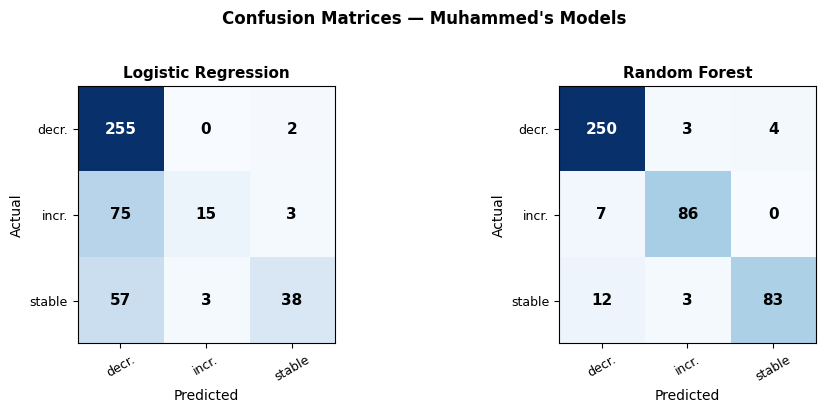

In [ ]:
import matplotlib.pyplot as plt, numpy as np

LABEL_NAMES = ["decr.","incr.","stable"]
model_preds = [("Logistic Regression", lr_pred), ("Random Forest", rf_pred)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Confusion Matrices — Muhammed's Models", fontsize=12, fontweight="bold", y=1.02)

for ax, (name, pred) in zip(axes, model_preds):
    cm_pd = pred.groupBy("labelIndex","prediction").count().toPandas()
    cm = (cm_pd.pivot(index="labelIndex", columns="prediction", values="count")
               .reindex(index=[0,1,2], columns=[0,1,2]).fillna(0).values)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1,2]); ax.set_xticklabels(LABEL_NAMES, rotation=30, fontsize=9)
    ax.set_yticks([0,1,2]); ax.set_yticklabels(LABEL_NAMES, fontsize=9)
    ax.set_xlabel("Predicted", fontsize=10); ax.set_ylabel("Actual", fontsize=10)
    ax.set_title(name, fontsize=11, fontweight="bold")
    mx = cm.max()
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i,j]), ha="center", va="center", fontsize=11,
                    fontweight="bold", color="white" if cm[i,j]>mx*0.6 else "black")

plt.tight_layout(); plt.show()

### Model Comparison — Accuracy & Weighted F1

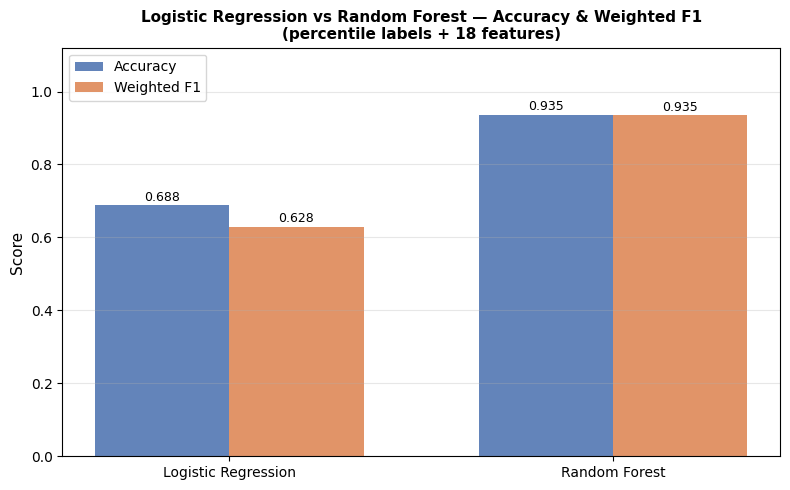

In [ ]:
import matplotlib.pyplot as plt, numpy as np

x, w = np.arange(len(all_results)), 0.35
labels = [r["model"] for r in all_results]

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, [r["accuracy"]    for r in all_results], w, label="Accuracy",    color="#4C72B0", alpha=0.87)
b2 = ax.bar(x + w/2, [r["weighted_f1"] for r in all_results], w, label="Weighted F1", color="#DD8452", alpha=0.87)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score", fontsize=11)
ax.set_title("Logistic Regression vs Random Forest — Accuracy & Weighted F1\n(percentile labels + 18 features)", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.12); ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**<h4>Build 5-Year and 10-Year Future Projections:<h4/>**

After training, we create future input rows for each country at 5-year and 10-year horizons. Each country's projected feature values are estimated from its most recent known values compounded by the average annual growth rate observed over the past 5 years. The better-performing model is then used to predict whether tourism is likely to be increasing, stable, or decreasing at each horizon.

In [ ]:
from pyspark.sql import Window
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

HORIZONS    = [5, 10]
N_YRS_TREND = 5

w_year = Window.partitionBy("country").orderBy("year")

trend_base = (df_ml
    .withColumn("arr_lag",  F.lag("arrivals_prev").over(w_year))
    .withColumn("rec_lag",  F.lag("receipts_prev").over(w_year))
    .withColumn("rpa_lag",  F.lag("rpa_prev").over(w_year))
    .withColumn("arr_logg", F.when((F.col("arrivals_prev")>0)&(F.col("arr_lag")>0),
                                   F.log(F.col("arrivals_prev")/F.col("arr_lag"))))
    .withColumn("rec_logg", F.when((F.col("receipts_prev")>0)&(F.col("rec_lag")>0),
                                   F.log(F.col("receipts_prev")/F.col("rec_lag"))))
    .withColumn("rpa_logg", F.when((F.col("rpa_prev")>0)&(F.col("rpa_lag")>0),
                                   F.log(F.col("rpa_prev")/F.col("rpa_lag"))))
)

last_year = trend_base.groupBy("country").agg(F.max("year").alias("last_year"))

last_row = (trend_base.join(last_year,"country")
    .filter(F.col("year")==F.col("last_year"))
    .select("country", F.col("last_year").alias("base_year"),
            F.col("arrivals_prev").alias("base_arr"), F.col("receipts_prev").alias("base_rec"),
            F.col("rpa_prev").alias("base_rpa"),     F.col("temp_prev").alias("base_temp_prev"),
            F.col("gdp").alias("base_gdp"),          F.col("avg_temp").alias("base_avg_temp"),
            F.col("temp_5yr_smooth").alias("base_temp_5yr_smooth"))
)

growth = (trend_base.join(last_year,"country")
    .filter(F.col("year") >= F.col("last_year") - (N_YRS_TREND - 1))
    .groupBy("country").agg(
        F.avg("arr_logg").alias("arr_logg_mean"),
        F.avg("rec_logg").alias("rec_logg_mean"),
        F.avg("rpa_logg").alias("rpa_logg_mean"),
        F.avg("temp_change").alias("temp_change_mean"))
).fillna(0.0)

base_future = last_row.join(growth,"country","left").fillna(0.0)
hdf = spark.createDataFrame([(int(h),) for h in HORIZONS], ["horizon"])

future = (base_future.crossJoin(hdf)
    .withColumn("year",          F.col("base_year") + F.col("horizon"))
    .withColumn("arrivals_prev", F.col("base_arr") * F.exp(F.col("horizon")*F.col("arr_logg_mean")))
    .withColumn("receipts_prev", F.col("base_rec") * F.exp(F.col("horizon")*F.col("rec_logg_mean")))
    .withColumn("rpa_prev",      F.col("base_rpa") * F.exp(F.col("horizon")*F.col("rpa_logg_mean")))
    .withColumn("arrivals_growth", F.col("arr_logg_mean"))
    .withColumn("receipts_growth", F.col("rec_logg_mean"))
    .withColumn("rpa_growth",      F.col("rpa_logg_mean"))
    .withColumn("temp_change",     F.col("temp_change_mean"))
    .withColumn("temp_prev",       F.col("base_temp_prev") + F.col("horizon")*F.col("temp_change_mean"))
    .withColumn("gdp",             F.col("base_gdp"))
    .withColumn("avg_temp",        F.col("base_avg_temp"))
    .withColumn("temp_5yr_smooth", F.col("base_temp_5yr_smooth"))
    .withColumn("log_arr_prev", F.log(F.when(F.col("arrivals_prev")>0, F.col("arrivals_prev"))))
    .withColumn("log_rec_prev", F.log(F.when(F.col("receipts_prev")>0, F.col("receipts_prev"))))
    .withColumn("log_rpa_prev", F.log(F.when(F.col("rpa_prev")>0,      F.col("rpa_prev"))))
    .withColumn("arr_slope", F.col("arr_logg_mean"))
    .withColumn("rec_slope", F.col("rec_logg_mean"))
    .withColumn("rpa_slope", F.col("rpa_logg_mean"))
    .select("country","horizon","year", *FEATURE_COLS)
    .dropna()
)

print("Future rows:", future.count())
future.show(5, truncate=False)

# Pick better model and predict
best_model = rf_model if rf_metrics["accuracy"] >= lr_metrics["accuracy"] else lr_model
best_name  = "Random Forest" if rf_metrics["accuracy"] >= lr_metrics["accuracy"] else "Logistic Regression"

future_for_pred = future.select("country", "horizon", *FEATURE_COLS).withColumn("label", F.lit("stable"))
pred_future     = best_model.transform(future_for_pred)

mapping_expr = F.create_map([F.lit(x) for x in sum([[float(i), s] for i, s in enumerate(LABEL_ORDER)], [])])
pred_future  = pred_future.withColumn("pred_label", mapping_expr[F.col("prediction")])

out = (pred_future
    .withColumn("prob_arr", vector_to_array("probability"))
    .select("country","horizon","year","pred_label","prob_arr")
    .orderBy("country","horizon")
)

wide = (out.groupBy("country")
    .pivot("horizon", [5, 10])
    .agg(F.first("pred_label"))
    .withColumnRenamed("5",  "proj_label_5y")
    .withColumnRenamed("10", "proj_label_10y")
    .orderBy("country")
)
wide.show(50, truncate=False)

out.groupBy("horizon","pred_label").count().orderBy("horizon","pred_label").show()
print(f"Model used for projection: {best_name}")

##**BigDM Algorithm 2 — Unsupervised Learning - Clustering (Shuroq)**

In this section, we apply clustering algorithms to group countries based on
similar tourism and climate trends.

Unlike supervised learning, clustering does not rely on labels. Instead,
it identifies natural groupings within the data based on feature similarity.

We use features capturing tourism growth, spending intensity, and climate
change signals to detect countries with similar travel evolution patterns.

- Prepare features for clustering (assemble and scale)
- Run K-Means clustering
- Output clusters DataFrame

In this step, we load the cleaned dataset generated in the previous section. This dataset already contains the processed tourism and climate features along with engineered variables such as growth rates and spending intensity. Loading the cleaned data ensures that the clustering algorithm operates on consistent and preprocessed inputs.

In [ ]:
# load cleaned dataset
DATA_PATH = "/content/drive/MyDrive/CS 483 Project/Datasets/cleaned_data.csv"

df = (spark.read.option("header", True)
                .option("inferSchema", True)
                .csv(DATA_PATH))

#just checking to see if we actually got the data correctly lol
print("Rows:", df.count())
print("Columns:", df.columns)

display(df.limit(5).toPandas())

For clustering, we select features that capture tourism growth patterns and climate changes over time. These include tourism growth metrics, spending intensity, and temperature changes. Removing rows with missing values ensures that the clustering algorithm receives complete numerical inputs.


Since our goal is to group countries rather than individual country-year observations, we aggregate the cleaned dataset to the country level. For each country, we compute average tourism and climate indicators across all available years, producing one row per country for clustering.


In [ ]:
from pyspark.sql import functions as F

#all the features we will be utilizing to effectively clustering
country_cluster_df = df.groupBy("country").agg(
    F.avg("arrivals_growth").alias("avg_arrivals_growth"),
    F.avg("receipts_growth").alias("avg_receipts_growth"),
    F.avg("rpa_growth").alias("avg_rpa_growth"),
    F.avg("temp_change").alias("avg_temp_change"),
    F.avg("avg_temp").alias("avg_temp"),
    F.avg("receipts_per_arrival").alias("avg_receipts_per_arrival")
).dropna()

#printing to ensure i did it right
print("Number of countries for clustering:", country_cluster_df.count())
display(country_cluster_df.limit(10).toPandas())

Spark ML requires all input variables to be combined into a single feature vector before applying machine learning algorithms. The VectorAssembler transforms the selected numerical features into a single vector column called features, which will be used as the input for the clustering model.

We then combine the aggregated country-level features into a single feature vector so they can be used as input to the K-Means clustering algorithm.

In [ ]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "avg_arrivals_growth",
    "avg_receipts_growth",
    "avg_rpa_growth",
    "avg_temp_change",
    "avg_temp",
    "avg_receipts_per_arrival"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

country_cluster_features = assembler.transform(country_cluster_df)

We evaluated clustering performance using silhouette analysis for values of k ranging from 2 to 8 on the country-level aggregated dataset. While k = 2 produced the highest silhouette score, it only created two broad groups and offered limited insight into tourism patterns. We selected k = 3 because it provides more balanced and interpretable country groupings while still maintaining a strong silhouette score.

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster"
)

silhouette_scores = []

#printing out all the silhouette scores
for k in range(2, 9):
    kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=42)
    model = kmeans.fit(country_cluster_features)
    predictions = model.transform(country_cluster_features)
    score = evaluator.evaluate(predictions)
    silhouette_scores.append((k, score))
    print(f"k = {k}, silhouette score = {score}")

We evaluated clustering performance using silhouette analysis for values of k ranging from 2 to 8 on the country-level aggregated dataset. While k = 2 produced the highest silhouette score, it resulted in only two broad clusters and therefore provided limited insight into tourism patterns. Among the remaining values, k = 3 produced one of the highest silhouette scores while also providing more balanced and interpretable groupings. Therefore, we selected k = 3 as the optimal number of clusters for our analysis.

In [ ]:
from pyspark.ml.clustering import KMeans

k = 3

kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=k,
    seed=42
)

kmeans_model = kmeans.fit(country_cluster_features)

country_clustered = kmeans_model.transform(country_cluster_features)

country_clustered.select("country", "cluster").show(20, truncate=False)

To evaluate the quality of the clusters produced by the K-Means algorithm, we compute the Silhouette Score. The Silhouette Score measures how well-separated the clusters are by comparing the distance of points within the same cluster to points in other clusters. Higher values indicate better cluster separation and more meaningful groupings.

In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster"
)

silhouette = evaluator.evaluate(country_clustered)

print("Silhouette Score:", silhouette)

In [ ]:
cluster_summary = country_clustered.groupBy("cluster").agg(
    F.avg("avg_arrivals_growth").alias("avg_arrivals_growth"),
    F.avg("avg_receipts_growth").alias("avg_receipts_growth"),
    F.avg("avg_rpa_growth").alias("avg_rpa_growth"),
    F.avg("avg_temp_change").alias("avg_temp_change"),
    F.avg("avg_receipts_per_arrival").alias("avg_receipts_per_arrival"),
    F.count("*").alias("num_countries")
)

cluster_summary.show(truncate=False)
country_clustered.groupBy("cluster").count().show()

Possible Interpretation of Each Cluster:

Cluster 0 (Emerging Destinations)

- highest arrivals growth

- highest receipts growth

- lowest receipts per arrival

- many countries

interpretation: fast-growing, lower-spend destinations

Cluster 2 (Stable destinations)

- moderate arrivals growth

- lower receipts growth than cluster 0

- higher receipts per arrival

interpretation: moderate-growth, mid-to-higher value destinations

Cluster 1 (Premium Destinations)

- slightly negative arrivals growth

- very high receipts per arrival

- highest rpa growth

interpretation: high-value, slower-growth destinations



All this information is important because it tells us the different groups we are working with when it comes ot recommending a country. Now lets try and see some example countries from each cluster.


In [ ]:
country_clustered.groupBy("cluster") \
    .agg(F.collect_set("country").alias("countries")) \
    .show(truncate=False)

Some Visualization:

In [ ]:
from pyspark.ml.feature import PCA

pca = PCA(k=2, inputCol="features", outputCol="pca_features")

pca_model = pca.fit(country_cluster_features)

pca_result = pca_model.transform(country_cluster_features)

pca_clustered = pca_result.join(
    country_clustered.select("country","cluster"),
    on="country"
)

To visualize the clustering structure, we applied Principal Component Analysis (PCA) to reduce the six-dimensional feature space to two components. The resulting scatter plot shows clear grouping of countries, supporting the validity of the K-means clustering results.

Each dot on the graph represents a country, and the color is the cluster they belong to. We plotted them based on Tourism and Climate features. We can see that cluster 0 is very compact, and then cluster 2 a little more spearate, and cluster 1 being an outlier group. Confimring our assumptions from earlier.

To visualize the clustering structure, we applied Principal Component Analysis (PCA) to reduce the six-dimensional feature space into two components. The scatter plot shows countries grouped into three clusters, with a large primary cluster, a moderate secondary cluster, and a small outlier cluster. The visual separation supports the validity of the K-Means clustering results.

In [ ]:
pandas_df = pca_clustered.select("country","cluster","pca_features").toPandas()
pandas_df["x"] = pandas_df["pca_features"].apply(lambda v: float(v[0]))
pandas_df["y"] = pandas_df["pca_features"].apply(lambda v: float(v[1]))
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for cluster in sorted(pandas_df["cluster"].unique()):
    subset = pandas_df[pandas_df["cluster"] == cluster]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cluster}", alpha=0.7)

plt.title("Country Clusters Based on Tourism and Climate Features")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

---

##**BigDM Algorithm 3 - Time Series Analysis - Trend Estimation & Forecasting (Shuroq)**

In this section, we analyze tourism trends over time and estimate future desirability using a simple time-series forecasting approach. Unlike clustering, which groups countries based on overall similarity, time-series analysis focuses on how each country’s tourism indicators evolve year by year. We use the country-year dataset to study long-term changes in travel desirability and project future trends.

In [ ]:
from pyspark.sql import functions as F

# features needed for this algorithm
ts_df = df.select(
    "country",
    "year",
    "arrivals_growth",
    "receipts_growth",
    "rpa_growth",
    "temp_change",
    "trend_score",
    "label_str"
).dropna()

print("Time series rows:", ts_df.count())
display(ts_df.orderBy("country", "year").limit(10).toPandas())

In [ ]:
yearly_trend = ts_df.groupBy("year").agg(
    F.avg("trend_score").alias("avg_trend_score")
).orderBy("year")

display(yearly_trend.toPandas())

In [ ]:
#the overall trend of global tourism, we see a steep decline in 2020 because of the COVID 19 Pandemic
import matplotlib.pyplot as plt
pdf = yearly_trend.toPandas()
plt.figure(figsize=(8,5))
plt.plot(pdf["year"], pdf["avg_trend_score"], marker='o')
plt.title("Global Tourism Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Trend Score")
plt.grid(True)
plt.show()

Now lets get to analyzing just individual countries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

pdf = ts_df.select("country", "year", "trend_score").toPandas()

country_trends = []

for country, group in pdf.groupby("country"):
    year_index = group["year"] - group["year"].min()
    X = year_index.values.reshape(-1,1)
    y = group["trend_score"].values

    model = LinearRegression()
    model.fit(X, y)

    slope = model.coef_[0]

    country_trends.append({
        "country": country,
        "trend_slope": slope
    })

trend_df = pd.DataFrame(country_trends)

print("Countries with increasing tourism trends")
trend_df.sort_values("trend_slope", ascending=False).head(10)

In [ ]:
print("Countries with declining tourism trends")
trend_df.sort_values("trend_slope").head(10)

Interpretation for Increasing Tourism Rates: For developing destinations this is common because tourism industries started
small, and moderate growth created large slows. this doesn't necessarily mean that they are the most visited country, it just
means that they had a faster growth rate.
Interpretation for Declining Tourism Rate: Makes sense because most of these countries have experienced political instability,
infrastructre issues, conflict, or travel restricts.

We evaluate the predictive accuracy of the time-series regression model using Root Mean Squared Error (RMSE), which measures the average difference between predicted trend scores and the observed values. Lower RMSE values indicate that the regression model closely fits the historical tourism trends.

In [ ]:
from sklearn.metrics import mean_squared_error

forecast_results = []

for country, group in pdf.groupby("country"):

    year_index = group["year"] - group["year"].min()

    X = year_index.values.reshape(-1,1)
    y = group["trend_score"].values

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    future_index = np.array([[year_index.max() + 1]])
    prediction = model.predict(future_index)[0]

    forecast_results.append({
        "country": country,
        "predicted_trend_next_year": prediction,
        "rmse": rmse
    })

forecast_df = pd.DataFrame(forecast_results)

forecast_df.sort_values("rmse").head(10)

The RMSE summary statistics below provide an overview of the prediction accuracy of the linear regression forecasting model across all countries. On average, the model produced an RMSE of approximately 0.23, indicating that predicted trend scores deviate moderately from the actual observed values. However, the median RMSE (0.106) is significantly lower than the mean, suggesting that most countries have relatively accurate predictions while a small number of outliers produce much larger errors.

The countries with the lowest RMSE values, such as the United Arab Emirates, Dominican Republic, and Iceland, demonstrate more stable tourism trends over time. Because their historical trend scores change more consistently, a simple linear regression model is able to approximate their future trend more accurately.

In contrast, the maximum RMSE value of 5.44 indicates that some countries experience highly volatile tourism patterns that are difficult to model using a simple linear trend. These large errors likely correspond to countries where tourism is affected by irregular events such as economic instability, policy changes, or external shocks. Overall, the results suggest that linear regression provides a reasonable baseline forecasting method for stable tourism markets, but more complex models may be required to accurately capture highly volatile trends.

The maximum RMSE value (5.44) indicates the presence of outliers in the forecasting results. These likely correspond to countries with limited historical observations or highly irregular tourism trends, which can cause simple linear regression models to produce unstable predictions.

In [ ]:
print("RMSE Summary Statistics")
print(forecast_df["rmse"].describe())

In [ ]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Type in Example country for visualization
country = "South Africa"

country_data = pdf[pdf["country"] == country].copy()

year_index = country_data["year"] - country_data["year"].min()
X = year_index.values.reshape(-1,1)
y = country_data["trend_score"].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE for {country}: {rmse:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred)

plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")
plt.xlabel("Actual Trend Score")
plt.ylabel("Predicted Trend Score")
plt.title(f"{country} Actual vs Predicted Trend Scores")
plt.grid(True)

plt.show()

Using a simple linear regression model, we forecasted the next-year trend score for each country. These predictions should be
interpreted primarily as relative indicators of future tourism momentum rather than exact long-term values, since simple linear
extrapolation can overestimate trends for countries with highly variable historical growth.

In [ ]:
country = "South Africa"
country_data = pdf[pdf["country"] == country].copy()
year_index = country_data["year"] - country_data["year"].min()
X = year_index.values.reshape(-1,1)
y = country_data["trend_score"].values
model = LinearRegression()
model.fit(X, y)
future_years = np.arange(country_data["year"].min(), 2026)
future_index = (future_years - country_data["year"].min()).reshape(-1,1)
pred = model.predict(future_index)
plt.figure(figsize=(8,5))
plt.scatter(country_data["year"], y, label="Observed")
plt.plot(future_years, pred, color="red", label="Trend + Forecast")
plt.title(f"{country} Tourism Trend Forecast")
plt.xlabel("Year")
plt.ylabel("Trend Score")
plt.legend()
plt.show()

---

## **Ranking System — Desirability Score (Sarah)**

In this section we build a **composite travel desirability score** for each of the 145 countries in the dataset and rank them from most to least desirable as travel destinations. Two rankings are produced and compared:

- **Average rank** — computed from each country's mean indicator values across all available years (2000–2020), reflecting long-term historical desirability
- **Recent rank** — computed from the most recent non-COVID year available per country (2019 for 99 out of 144 countries), reflecting current desirability

Comparing both rankings reveals which destinations are improving or declining. A country ranked much higher recently than historically is gaining momentum, while one ranked much lower recently than historically is losing appeal.



### Indicators and Weights

The composite score combines seven indicators selected to capture tourism momentum, spending quality, destination scale, climate, economic development, and climate stability:

| Indicator | What it measures | Weight |
|-----------|-----------------|--------|
| `trend_score` | Weighted combination of arrivals growth and spending-per-arrival growth — the same signal driving classification in Algorithms 1 and 4 | 30% |
| `receipts_per_arrival` | Revenue earned per tourist — captures spending quality and destination value per visitor | 20% |
| `tourism_arrivals` | Absolute number of tourists visiting — destination scale and global popularity | 15% |
| `tourism_receipts` | Total tourism revenue in absolute terms — economic weight of tourism | 15% |
| `avg_temp` | Average annual temperature — climate appeal for tourists | 10% |
| `gdp` | Gross domestic product — economic development and infrastructure quality | 5% |
| `temp_change` | Year-over-year temperature change — climate stability (inverted) | 5% |

`trend_score` is weighted highest at 30% to maintain consistency with the classification work — it directly captures tourism momentum and is the same signal that explained 96.4% of classification splits. `tourism_arrivals` and `tourism_receipts` (15% each) were added to ground the ranking in real-world scale — without them, small high-growth countries would dominate over globally significant destinations. `temp_change` is inverted so that climate instability reduces a country's score.

### Load Data and Define Indicators

We load the cleaned dataset and define the seven indicators with their weights. The `INVERTED` set flags `temp_change` for inversion during normalization — since lower temperature volatility is better for tourism, its normalized value is flipped so that a stable climate contributes positively to the score.

**Note on 2020:** 2020 is excluded from the recent ranking only since COVID-19 pandemic shutdowns make 2020 tourism values unrepresentative. It is still included when computing the all-years average.

In [ ]:
from pyspark.sql import SparkSession, functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

spark = SparkSession.builder.getOrCreate()

DATA_PATH = "/content/drive/MyDrive/CS 483 Project/Datasets/cleaned_data.csv"

df = (spark.read
          .option("header", True)
          .option("inferSchema", True)
          .csv(DATA_PATH))

print(f"Total rows: {df.count()} | Countries: {df.select('country').distinct().count()}")

# Seven indicators and weights
INDICATORS = [
    "trend_score",
    "receipts_per_arrival",
    "tourism_arrivals",
    "tourism_receipts",
    "avg_temp",
    "gdp",
    "temp_change"
]

WEIGHTS = {
    "trend_score":          0.30,
    "receipts_per_arrival": 0.20,
    "tourism_arrivals":     0.15,
    "tourism_receipts":     0.15,
    "avg_temp":             0.10,
    "gdp":                  0.05,
    "temp_change":          0.05   # inverted — lower temp_change = better
}

# temp_change is inverted: high instability = lower score
INVERTED = {"temp_change"}

print("\nIndicators and weights:")
for k, v in WEIGHTS.items():
    note = " (inverted)" if k in INVERTED else ""
    print(f"  {k:<25} {int(v*100)}%{note}")
print(f"  Total: {int(sum(WEIGHTS.values())*100)}%")

### Average Desirability Score (All Years)

We aggregate each of the seven indicators to country level by averaging across all available years (2000–2020). This gives one row per country representing its typical historical behaviour on each indicator.

Each indicator is then **min-max normalized** to a 0–1 scale:
- For regular indicators: `normalized = (value - min) / (max - min)`
- For `temp_change` (inverted): `normalized = 1 - (value - min) / (max - min)`

This makes all indicators comparable regardless of their original units (GDP in billions, arrivals in millions, trend_score as a small decimal). The composite score is then computed as the weighted sum: `score = 0.30×trend + 0.20×rpa + 0.15×arrivals + 0.15×receipts + 0.10×temp + 0.05×gdp + 0.05×stability`

**Top result:** United States ranks #1 on the average ranking (score 0.4202), followed by Congo Dem. Rep. (0.4183) and Qatar (0.3601). The US leads because it scores highly on absolute tourism scale, tens of millions of arrivals and billions in receipts combined with a warm average climate and strong GDP. Congo ranks #2 due to exceptionally high trend_score from rapid tourism growth, even though its absolute visitor numbers are small.

In [ ]:
# Aggregate to country level
avg_df = (df
    .groupBy("country")
    .agg(
        F.avg("trend_score").alias("trend_score"),
        F.avg("receipts_per_arrival").alias("receipts_per_arrival"),
        F.avg("tourism_arrivals").alias("tourism_arrivals"),
        F.avg("tourism_receipts").alias("tourism_receipts"),
        F.avg("avg_temp").alias("avg_temp"),
        F.avg("gdp").alias("gdp"),
        F.avg("temp_change").alias("temp_change")
    )
    .dropna()
    .toPandas()
)

print(f"Countries after aggregation: {len(avg_df)}")

# Min-max normalize
avg_norm = avg_df.copy()
for col in INDICATORS:
    mn, mx = avg_df[col].min(), avg_df[col].max()
    normalized = (avg_df[col] - mn) / (mx - mn)
    avg_norm[col] = (1 - normalized) if col in INVERTED else normalized

# Weighted composite score
avg_norm["desirability_score"] = sum(
    avg_norm[col] * WEIGHTS[col] for col in INDICATORS
)

# Rank
avg_norm["avg_rank"] = avg_norm["desirability_score"].rank(
    ascending=False, method="min"
).astype(int)

avg_ranked = (avg_norm[["country","desirability_score","avg_rank"]]
              .sort_values("avg_rank")
              .reset_index(drop=True))
avg_ranked.columns = ["Country","Avg Score","Avg Rank"]
avg_ranked["Avg Score"] = avg_ranked["Avg Score"].round(4)

print("\nTop 20 countries by average desirability score (all years):")
display(avg_ranked.head(20))

### Recent Desirability Score (Most Recent Non-COVID Year)

Instead of averaging all years, we take each country's most recent available year excluding 2020. For 99 out of 144 countries (69%) this is 2019, making the recent ranking highly consistent for the majority. For the remaining 45 countries, the most recent available year ranges from 2002 to 2018 due to data gaps in the source dataset.

**On consistency across different years:** Countries whose most recent data is older than 2019 (e.g. Spain uses 2013, Kiribati uses 2017) are scored against the same normalized scale as all other countries — so their scores are internally consistent. However, older years may understate or overstate current performance for countries where tourism changed significantly after their last data point. The `Year Used` column in the combined table makes this transparent to account for it when interpreting individual country results.


In [ ]:
# Most recent non-2020 year per country
recent_df = (df
    .filter(F.col("year") != 2020)
    .groupBy("country")
    .agg(F.max("year").alias("most_recent_year"))
)

recent_data = (df
    .filter(F.col("year") != 2020)
    .join(recent_df, on="country")
    .filter(F.col("year") == F.col("most_recent_year"))
    .select("country", "most_recent_year", *INDICATORS)
    .dropna()
    .toPandas()
)

print(f"Countries with recent data: {len(recent_data)}")
print("Most recent year distribution:")
print(recent_data["most_recent_year"].value_counts().sort_index())

# Min-max normalize — invert temp_change
recent_norm = recent_data.copy()
for col in INDICATORS:
    mn, mx = recent_data[col].min(), recent_data[col].max()
    normalized = (recent_data[col] - mn) / (mx - mn)
    recent_norm[col] = (1 - normalized) if col in INVERTED else normalized

# Weighted composite score
recent_norm["desirability_score"] = sum(
    recent_norm[col] * WEIGHTS[col] for col in INDICATORS
)

# Rank
recent_norm["recent_rank"] = recent_norm["desirability_score"].rank(
    ascending=False, method="min"
).astype(int)

recent_ranked = (recent_norm[["country","desirability_score","recent_rank","most_recent_year"]]
                 .sort_values("recent_rank")
                 .reset_index(drop=True))
recent_ranked.columns = ["Country","Recent Score","Recent Rank","Year Used"]
recent_ranked["Recent Score"] = recent_ranked["Recent Score"].round(4)

print("\nTop 20 countries by recent desirability score:")
display(recent_ranked.head(20))

### Combined Ranking Table (All 144 Countries)

We merge the average and recent rankings into a single table. Each country shows both its historical rank and its current rank side by side.

The **Rank Change** column is computed as `Average Rank − Recent Rank`. A positive value means the country ranks better recently than its historical average it is currently more desirable than it used to be. A negative value means it has declined. Countries that moved more than 3 positions are flagged:

- **▲ Improving** — ranked at least 4 positions better recently than historically
- **▼ Declining** — ranked at least 4 positions worse recently than historically
- **● Stable** — position changed by 3 or fewer ranks

**Note on year consistency:** 99 of 144 countries (69%) use 2019 as their recent year, making direct comparison reliable for the majority. For the remaining 45 countries, older years are used due to data availability gaps. The `Year Used` indicates which year was used

In [ ]:
combined = pd.merge(avg_ranked, recent_ranked, on="Country", how="inner")

combined["Rank Change"] = combined["Avg Rank"] - combined["Recent Rank"]
combined["Trend"] = combined["Rank Change"].apply(
    lambda x: "▲ Improving" if x > 3 else ("▼ Declining" if x < -3 else "● Stable")
)

combined = combined.sort_values("Recent Rank").reset_index(drop=True)
combined.index += 1

print(f"Full ranking — {len(combined)} countries")

display_df = combined[["Country","Avg Rank","Avg Score",
                        "Recent Rank","Recent Score",
                        "Rank Change","Trend","Year Used"]].copy()
display_df["Avg Score"]    = display_df["Avg Score"].map("{:.4f}".format)
display_df["Recent Score"] = display_df["Recent Score"].map("{:.4f}".format)
display_df["Rank Change"]  = display_df["Rank Change"].map("{:+d}".format)

def color_trend(val):
    if "Improving" in str(val): return "color: green; font-weight: bold"
    if "Declining" in str(val): return "color: red; font-weight: bold"
    return ""

display(display_df.style.map(color_trend, subset=["Trend"]))

### Top 10 and Bottom 10 Destinations

The bar charts show the 10 most and 10 least desirable destinations by recent composite score, color coded by trend direction.

**Top 10 interpretation:**
The top destinations are dominated by countries that combine strong absolute tourism scale with warm climates and solid economies. The United States leads at 0.427 — the world's largest tourism economy by receipts. France (0.293) and Spain (0.217) appear for the first time in the top 10 compared to the previous version without scale indicators, confirming that adding `tourism_arrivals` and `tourism_receipts` produces a more realistic global ranking. Three countries show green (▲ Improving): Luxembourg, Ethiopia, and Thailand — all had notably stronger recent years than their historical averages.

**Bottom 10 interpretation:**
The bottom 10 are predominantly cold northern and central European/Asian countries — Ukraine, Slovak Republic, Estonia, Russian Federation, Mongolia, Latvia, Belarus, Norway, Tajikistan, and Kazakhstan. Their low scores reflect a combination of low `avg_temp` (10% weight), relatively low absolute tourism volumes compared to global leaders, and limited spending per arrival. This is a known limitation of including temperature as an indicator — it reflects tourist climate appeal rather than overall country quality, and does not capture winter tourism markets.

In [ ]:
top10    = combined.nsmallest(10, "Recent Rank")[["Country","Recent Score","Trend"]].reset_index(drop=True)
bottom10 = combined.nlargest(10,  "Recent Rank")[["Country","Recent Score","Trend"]].reset_index(drop=True)

color_map = {"▲ Improving":"#2ecc71","▼ Declining":"#e74c3c","● Stable":"#3498db"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10
colors_top = [color_map[t] for t in top10["Trend"]]
axes[0].barh(top10["Country"][::-1], top10["Recent Score"][::-1],
             color=colors_top[::-1], edgecolor="white")
axes[0].set_title("Top 10 Most Desirable Destinations", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Composite Desirability Score", fontsize=10)
axes[0].set_xlim(0, 1.05)
axes[0].grid(axis="x", alpha=0.3)
for i, score in enumerate(top10["Recent Score"][::-1]):
    axes[0].text(score + 0.01, i, f"{score:.3f}", va="center", fontsize=9)

# Bottom 10
colors_bot = [color_map[t] for t in bottom10["Trend"]]
axes[1].barh(bottom10["Country"][::-1], bottom10["Recent Score"][::-1],
             color=colors_bot[::-1], edgecolor="white")
axes[1].set_title("Bottom 10 Least Desirable Destinations", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Composite Desirability Score", fontsize=10)
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis="x", alpha=0.3)
for i, score in enumerate(bottom10["Recent Score"][::-1]):
    axes[1].text(score + 0.005, i, f"{score:.3f}", va="center", fontsize=9)

green = mpatches.Patch(color="#2ecc71", label="▲ Improving")
red   = mpatches.Patch(color="#e74c3c", label="▼ Declining")
blue  = mpatches.Patch(color="#3498db", label="● Stable")
fig.legend(handles=[green, red, blue], loc="lower center",
           ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle(
    "Travel Desirability Rankings\n"
    "(trend 30% | receipts/arrival 20% | arrivals 15% | receipts 15% | temp 10% | gdp 5% | stability 5%)",
    fontsize=10, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.show()

In [ ]:
# Get top 3 and bottom 3
top3 = combined.nsmallest(3, "Recent Rank")[["Country","Recent Score","Trend"]]
bottom3 = combined.nlargest(3, "Recent Rank")[["Country","Recent Score","Trend"]]

# Combine them
combined_6 = pd.concat([top3, bottom3]).reset_index(drop=True)

# Sort for better visual flow
combined_6 = combined_6.sort_values("Recent Score", ascending=False)

color_map = {"▲ Improving":"#2ecc71","▼ Declining":"#e74c3c","● Stable":"#3498db"}
colors = [color_map[t] for t in combined_6["Trend"]]

# Vertical bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(combined_6["Country"], combined_6["Recent Score"],
               color=colors, edgecolor="white")

plt.title("Top 3 and Bottom 3 Travel Destinations", fontsize=12, fontweight="bold")
plt.ylabel("Composite Desirability Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

# Rotate x labels for readability
plt.xticks(rotation=30, ha="right")

# Add value labels on top of bars
for i, score in enumerate(combined_6["Recent Score"]):
    plt.text(i, score + 0.02, f"{score:.3f}", ha="center", fontsize=9)

# Legend
green = mpatches.Patch(color="#2ecc71", label="▲ Improving")
red   = mpatches.Patch(color="#e74c3c", label="▼ Declining")
blue  = mpatches.Patch(color="#3498db", label="● Stable")
plt.legend(handles=[green, red, blue], loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Get top 3 and bottom 3
top3 = combined.nsmallest(3, "Recent Rank")[["Country","Recent Score","Trend"]]
bottom3 = combined.nlargest(3, "Recent Rank")[["Country","Recent Score","Trend"]]

# Combine them
combined_6 = pd.concat([top3, bottom3]).reset_index(drop=True)

# Sort so it looks clean in graph (optional)
combined_6 = combined_6.sort_values("Recent Score")

color_map = {"▲ Improving":"#2ecc71","▼ Declining":"#e74c3c","● Stable":"#3498db"}
colors = [color_map[t] for t in combined_6["Trend"]]

# Single plot
plt.figure(figsize=(8, 5))
plt.barh(combined_6["Country"], combined_6["Recent Score"],
         color=colors, edgecolor="white")

plt.title("Top 3 and Bottom 3 Travel Destinations", fontsize=12, fontweight="bold")
plt.xlabel("Composite Desirability Score")
plt.xlim(0, 1.05)
plt.grid(axis="x", alpha=0.3)

# Add labels
for i, score in enumerate(combined_6["Recent Score"]):
    plt.text(score + 0.01, i, f"{score:.3f}", va="center", fontsize=9)

# Legend
green = mpatches.Patch(color="#2ecc71", label="▲ Improving")
red   = mpatches.Patch(color="#e74c3c", label="▼ Declining")
blue  = mpatches.Patch(color="#3498db", label="● Stable")
plt.legend(handles=[green, red, blue], loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

### Average vs Recent Rank Scatter Plot

Every country is plotted with its average rank (x-axis) against its recent rank (y-axis). The dashed diagonal line represents no change between average and recent. Countries **below** the diagonal have improved recently — their recent rank number is lower (better) than their average. Countries **above** the diagonal have declined.

**Most improved (largest positive rank change):**
Jordan improved by 50 positions — from average rank #95 to recent rank #45 — the largest single jump in the dataset, driven by a major recovery in 2019 tourism. Poland (+36), Grenada (+34), Austria (+33), and Hungary (+30) all show strong recent momentum, particularly in 2019 which was a peak year for European tourism.

**Most declined (largest negative rank change):**
Guinea dropped 85 positions — from average rank #5 to recent rank #90. Its historical average was inflated by exceptional early-2000s growth that was not sustained into recent years. Papua New Guinea (-80) shows the same pattern. Bhutan (-50) declined due to reduced arrivals following policy changes on tourist fees. Uzbekistan (-40) had strong historical growth that slowed in recent years. The United Kingdom (-24) is notable — its average rank is #67 but recent rank is #91, partly because its most recent data year in this dataset is 2013, which predates several years of strong UK tourism growth.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = [color_map[t] for t in combined["Trend"]]
ax.scatter(combined["Avg Rank"], combined["Recent Rank"],
           c=colors, alpha=0.75, s=65, edgecolors="white", linewidth=0.5)

max_rank = int(combined["Avg Rank"].max())
ax.plot([1, max_rank], [1, max_rank], "k--", alpha=0.25)

label_set = set(top10["Country"].tolist() + bottom10["Country"].tolist())
for _, row in combined.iterrows():
    if row["Country"] in label_set:
        ax.annotate(row["Country"],
                    (row["Avg Rank"], row["Recent Rank"]),
                    fontsize=7, alpha=0.9,
                    xytext=(4, 4), textcoords="offset points")

green = mpatches.Patch(color="#2ecc71", label="▲ Improving")
red   = mpatches.Patch(color="#e74c3c", label="▼ Declining")
blue  = mpatches.Patch(color="#3498db", label="● Stable")
ax.legend(handles=[green, red, blue], fontsize=9)
ax.set_xlabel("Average Rank (all years)", fontsize=11)
ax.set_ylabel("Recent Rank (most recent year)", fontsize=11)
ax.set_title("Average vs Recent Desirability Rank\n"
             "(below diagonal = improving recently, above = declining)",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Most improved recently (largest positive rank change):")
display(combined.nlargest(10, "Rank Change")
                [["Country","Avg Rank","Recent Rank","Rank Change","Trend"]])

print("\nMost declined recently (largest negative rank change):")
display(combined.nsmallest(10, "Rank Change")
                [["Country","Avg Rank","Recent Rank","Rank Change","Trend"]])

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

COLOR_MAP = {
    "▲ Improving": "#2ecc71",
    "▼ Declining": "#e74c3c",
    "● Stable":    "#3498db",
}

def bar_colors(trends):
    return [COLOR_MAP[t] for t in trends]

patches = [
    mpatches.Patch(color="#2ecc71", label="▲ Improving"),
    mpatches.Patch(color="#e74c3c", label="▼ Declining"),
    mpatches.Patch(color="#3498db", label="● Stable"),
]

# Biggest rank changes (diverging bar)

combined["Rank Change Num"] = combined["Avg Rank"].astype(int) \
                            - combined["Recent Rank"].astype(int)

top_imp = combined.nlargest(10, "Rank Change Num")[
    ["Country", "Rank Change Num", "Trend"]
]
top_dec = combined.nsmallest(5, "Rank Change Num")[
    ["Country", "Rank Change Num", "Trend"]
]
change_df = pd.concat([top_dec, top_imp]).sort_values("Rank Change Num")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    change_df["Country"],
    change_df["Rank Change Num"],
    color=[COLOR_MAP[t] for t in change_df["Trend"]],
    edgecolor="white",
    height=0.6,
)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Rank change  (positive = improved recently)", fontsize=11)
ax.set_title(
    "Biggest Rank Changes: Avg → Recent\n"
    "Top 10 improvers & Top 5 decliners",
    fontsize=12, fontweight="bold",
)
ax.grid(axis="x", alpha=0.3)

for _, row in change_df.iterrows():
    v = row["Rank Change Num"]
    ax.text(
        v + (1 if v >= 0 else -1),
        row["Country"],
        f"{v:+d}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9,
    )

ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.show()

### Conclusion — Ranking System

The composite desirability ranking scores all 144 countries on seven indicators covering tourism momentum, spending quality, destination scale, climate, economic development, and climate stability.

**Key findings from the ranking:**

The **United States** leads both the average and recent rankings, driven by the largest absolute tourism economy in the dataset. **France** and **Spain** rank in the top 10 for the first time after adding scale indicators, correctly positioning two of the world's most visited countries. **Qatar** ranks consistently at #3 due to extremely high spending per arrival and strong GDP. **Congo Dem. Rep.** remains in the top 3 due to exceptional trend_score from rapid tourism growth — a legitimate finding that reflects real momentum even if absolute visitor numbers are small.

The ranking directly connects to the classification results from Algorithms 1 and 4. Countries labelled "increasing" by the classifiers generally show positive rank changes in the ranking (Jordan +50, Poland +36, Ethiopia improving), while countries labelled "decreasing" show negative rank changes (Guinea -85, Papua New Guinea -80, Bhutan -50). This validates that the classifier and the ranking system are capturing the same underlying tourism trajectory signal from two different analytical perspectives.

**Limitations:**

Cold-climate countries (Russia, Norway, Canada, Estonia) rank low partly due to the 10% weight on `avg_temp`, which reflects tourist climate appeal but does not capture winter tourism markets or non-weather-driven travel demand. Additionally, 45 of 144 countries use data older than 2019 for the recent ranking due to source dataset gaps — their recent scores reflect their last available year rather than a true 2019 snapshot, which should be noted when interpreting individual country results.